In [1]:
## Importar bibliotecas generales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pylab import *

## PySpark
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark import SparkConf
from pyspark.sql import functions as F
from pyspark.sql.functions import (
    col, when, count, avg, sum as Fsum, trim, upper,
    regexp_replace, isnull, percentile_approx, stddev
)
from pyspark.sql.types import *

## ML — PySpark MLlib
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    VectorAssembler, StringIndexer, StandardScaler, Imputer
)
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.clustering import BisectingKMeans
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
    ClusteringEvaluator
)
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

## Sklearn para métricas adicionales
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

print("Bibliotecas cargadas correctamente")

Bibliotecas cargadas correctamente


In [2]:
### Se requiere levantar la sesión para Trabajar con los Servicios
### Basados en SPARK: Procesamiento Paralelo y Distribuido sobre Grandes Volumenes de Datos
configura = SparkConf()
configura.setAppName("icfes_SPARK")                                           #--- Nombre de la aplicación
configura.set("spark.scheduler.mode","FAIR")                                        #---Configuracion de tipo "FAIR" para que sea justo y equitativo. 
                                                                                    #---Se requiere que multiples usuarios tengan recursos concurrentemente
configura.set("spark.scheduler.allocation","/Almacen/Spark/conf/fairscheduler.xml") #---Ubicación xml de la configuración FAIR
configura.setMaster("spark://10.43.97.207:7077")                                    #---Se configura en la dirección del MASTER
sparkB = SparkSession.builder.config(conf=configura).getOrCreate()                  #---Se crea la sesión
print("Sesión creada: Proyecto ICFES")
sparkB

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/26 02:04:54 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Sesión creada: Proyecto ICFES


In [3]:
dfICFES = sparkB.read.format("csv").option("header", "true").load("Proyecto/Resultados_únicos_Saber_11_20260525.csv")
dfICFES.show(5)

26/05/26 02:05:18 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 1:>                                                          (0 + 1) / 1]

+-------+------------------+----------------+-------------------+-------------+---------------+-----------------+-----------------------------+------------------+------------------------+------------------------+-----------------+--------------------+-----------+------------+--------------------+---------------+---------------------------+----------------+-------------------+---------------------------+---------------------------+---------------------+---------------------+-----------------------+-----------------+------------------------+---------------+--------------------+-----------+-----------------------+-----------------+-----------------+----------------+---------------------+-----------------+--------------------+--------------------+--------------------+------------------+-------------------+--------------------+------------------+------------------+-------------+-----------+----------------+------------------------+----------------+--------------------+-----------+
|PERIODO|

In [4]:
dfEducacion = sparkB.read.format("csv").option("header", "true").load("Proyecto/educacion.csv")
dfEducacion.show(5)

+----+----------------+-------------+-------------------+------------+----------+---------------+--------------+-----------------------+--------------+-------------------------+-----------------------+-------------------------+--------------------+---------------+--------------------------+------------------------+--------------------------+---------------------+------------------------+---------------------------+---------+--------------------+------------------+--------------------+---------------+----------+---------------------+-------------------+---------------------+----------------+-----------+----------------------+--------------------+----------------------+-----------------+----------+---------------------+-------------------+---------------------+----------------+
| AÑO|CÓDIGO_MUNICIPIO|    MUNICIPIO|CÓDIGO_DEPARTAMENTO|DEPARTAMENTO|CÓDIGO_ETC|            ETC|POBLACIÓN_5_16|TASA_MATRICULACIÓN_5_16|COBERTURA_NETA|COBERTURA_NETA_TRANSICIÓN|COBERTURA_NETA_PRIMARIA|COBERTURA_NE

In [5]:
dfBeneficiarios = sparkB.read.format("csv").option("header", "true").load("Proyecto/Beneficiarios_Estrategia_UNIDOS_20260525.csv")
dfBeneficiarios.show(5)

[Stage 5:>                                                          (0 + 1) / 1]

+-------------+-------------+---------+----+--------------------------+--------------------------+-----------------------+-----------------------+-------------+------------------+---------------+------------+---------------+-------+-----+------+-----------------+-------------+------------------+---------+---------+---------+------------+---------+---------+---------+---------+---------+------------+---------+---------+---------+---------+------------+------------+---------+------------+------------+------------+---------+---------+------------+---------+------------+------------+----+----+----+----+----+----+----+----+------------------+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+----+
|CodigoFamilia|TipoDocumento|RangoEdad|Pais|CodigoDepartamentoAtencion|NombreDepartamentoAtencion|CodigoMunicipioAtencion|NombreMunicipioAtencion|PuntajeSISBEN|BeneficiarioSISBEN|CondicionSexual|Discapacidad|    EstadoCivil|Estrato|Etnia|Genero|       Parente

In [6]:
dfInternet = sparkB.read.format("csv").option("header", "true").load("Proyecto/Internet_Fijo_Accesos_por_tecnología_y_segmento_20260525.csv")
dfInternet.show(5)

+----+---------+--------------------+----------------+------------+-------------+--------------------+--------------------+----------+----------------+----------------+-------------+
| AÑO|TRIMESTRE|           PROVEEDOR|COD_DEPARTAMENTO|DEPARTAMENTO|COD_MUNICIPIO|           MUNICIPIO|            SEGMENTO|TECNOLOGIA|VELOCIDAD_BAJADA|VELOCIDAD_SUBIDA|No DE ACCESOS|
+----+---------+--------------------+----------------+------------+-------------+--------------------+--------------------+----------+----------------+----------------+-------------+
|2018|        1|         EDATEL S.A.|              05|   ANTIOQUIA|        05042|SANTAFÉ DE ANTIOQUIA|         CORPORATIVO|      XDSL|            8,00|            1,00|           25|
|2019|        1|AXESS NETWORKS SO...|              52|      NARIÑO|        52473|            MOSQUERA|         CORPORATIVO| SATELITAL|            0,06|            0,06|            2|
|2019|        1|TELMEX COLOMBIA S.A.|              25|CUNDINAMARCA|        25269|    

In [7]:
# ── Castear puntajes a numérico 
cols_puntaje = [
    "PUNT_INGLES", "PUNT_MATEMATICAS", "PUNT_SOCIALES_CIUDADANAS",
    "PUNT_C_NATURALES", "PUNT_LECTURA_CRITICA", "PUNT_GLOBAL"
]

dfICFES2 = dfICFES
for c in cols_puntaje:
    dfICFES2 = dfICFES2.withColumn(c, col(c).cast("double"))

dfICFES2 = dfICFES2.withColumn("PERIODO", col("PERIODO").cast("integer"))

print("Total registros:", dfICFES2.count())
dfICFES2.printSchema()

[Stage 8:======================================================>  (27 + 1) / 28]

Total registros: 7109704
root
 |-- PERIODO: integer (nullable = true)
 |-- ESTU_TIPODOCUMENTO: string (nullable = true)
 |-- ESTU_CONSECUTIVO: string (nullable = true)
 |-- COLE_AREA_UBICACION: string (nullable = true)
 |-- COLE_BILINGUE: string (nullable = true)
 |-- COLE_CALENDARIO: string (nullable = true)
 |-- COLE_CARACTER: string (nullable = true)
 |-- COLE_COD_DANE_ESTABLECIMIENTO: string (nullable = true)
 |-- COLE_COD_DANE_SEDE: string (nullable = true)
 |-- COLE_COD_DEPTO_UBICACION: string (nullable = true)
 |-- COLE_COD_MCPIO_UBICACION: string (nullable = true)
 |-- COLE_CODIGO_ICFES: string (nullable = true)
 |-- COLE_DEPTO_UBICACION: string (nullable = true)
 |-- COLE_GENERO: string (nullable = true)
 |-- COLE_JORNADA: string (nullable = true)
 |-- COLE_MCPIO_UBICACION: string (nullable = true)
 |-- COLE_NATURALEZA: string (nullable = true)
 |-- COLE_NOMBRE_ESTABLECIMIENTO: string (nullable = true)
 |-- COLE_NOMBRE_SEDE: string (nullable = true)
 |-- COLE_SEDE_PRINCIPAL: s

In [8]:
from pyspark.sql import functions as F

cols_key_icfes = [
    "PERIODO", "COLE_AREA_UBICACION", "COLE_DEPTO_UBICACION",
    "COLE_MCPIO_UBICACION", "COLE_NATURALEZA", "ESTU_GENERO",
    "PUNT_MATEMATICAS", "PUNT_C_NATURALES", "PUNT_LECTURA_CRITICA", 
    "PUNT_GLOBAL"
]

dfICFES2.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in cols_key_icfes
]).toPandas()


,PERIODO,COLE_AREA_UBICACION,COLE_DEPTO_UBICACION,COLE_MCPIO_UBICACION,COLE_NATURALEZA,ESTU_GENERO,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL
0,0,3031,23,23,23,3406,7,2609523,2609523,2609523


In [9]:
# ── Extracción del AÑO desde PERIODO 
dfICFES3 = dfICFES2.withColumn("AÑO", (col("PERIODO") / 10).cast("integer"))

dfICFES3.select("PERIODO", "AÑO").distinct().orderBy("AÑO").show()

[Stage 14:======================================================> (27 + 1) / 28]

+-------+----+
|PERIODO| AÑO|
+-------+----+
|  20101|2010|
|  20102|2010|
|  20111|2011|
|  20112|2011|
|  20121|2012|
|  20122|2012|
|  20131|2013|
|  20132|2013|
|  20142|2014|
|  20141|2014|
|  20151|2015|
|  20152|2015|
|  20162|2016|
|  20161|2016|
|  20172|2017|
|  20171|2017|
|  20181|2018|
|  20194|2019|
|  20191|2019|
|  20201|2020|
+-------+----+
only showing top 20 rows



In [10]:
# ── Filtros iniciales: periodos >= 2014, puntaje global válido, Colombia 
dfICFES_clean = dfICFES3 \
    .filter(col("AÑO") >= 2014) \
    .filter(col("PUNT_GLOBAL").isNotNull()) \
    .filter(col("ESTU_PAIS_RESIDE") == "COLOMBIA")

print("Registros originales:", dfICFES3.count())
print("Registros después de filtros:", dfICFES_clean.count())

Registros originales: 7109704


[Stage 20:======================================================> (27 + 1) / 28]

Registros después de filtros: 4481663


In [11]:
from pyspark.sql.functions import regexp_replace

# ── Limpieza de encoding en departamento BOGOTA/BOGOTÁ 
dfICFES_clean = dfICFES_clean \
    .withColumn("COLE_DEPTO_UBICACION",
                regexp_replace(
                    upper(trim(col("COLE_DEPTO_UBICACION"))),
                    "BOGOTÁ", "BOGOTA")) \
    .withColumn("ESTU_DEPTO_RESIDE",
                regexp_replace(
                    upper(trim(col("ESTU_DEPTO_RESIDE"))),
                    "BOGOTÁ", "BOGOTA"))

dfICFES_clean.groupBy("COLE_DEPTO_UBICACION") \
    .count().filter(col("COLE_DEPTO_UBICACION").like("%BOG%")).show()

[Stage 23:======================================================> (27 + 1) / 28]

+--------------------+------+
|COLE_DEPTO_UBICACION| count|
+--------------------+------+
|              BOGOTA|709169|
+--------------------+------+



In [12]:
# ── Normalización de municipio (tildes) — necesario para focalización Entrega 2 ──
dfICFES_clean = dfICFES_clean \
    .withColumn("COLE_MCPIO_UBICACION",
                regexp_replace(upper(trim(col("COLE_MCPIO_UBICACION"))), "Ó", "O"))

dfICFES_clean.select("COLE_MCPIO_UBICACION").distinct() \
    .filter(col("COLE_MCPIO_UBICACION").like("%BOG%") |
            col("COLE_MCPIO_UBICACION").like("%QUIB%") |
            col("COLE_MCPIO_UBICACION").like("%PAST%")).show()

[Stage 26:======================================================> (27 + 1) / 28]

+--------------------+
|COLE_MCPIO_UBICACION|
+--------------------+
|               PASTO|
|              QUIBDO|
|         BOGOTÁ D.C.|
+--------------------+



In [13]:
# ── Variable binaria internet en hogar 
dfICFES_clean = dfICFES_clean \
    .withColumn("TIENE_INTERNET_BIN",
                when(col("FAMI_TIENEINTERNET") == "Si", 1.0)
                .when(col("FAMI_TIENEINTERNET") == "No", 0.0)
                .otherwise(None))

dfICFES_clean.groupBy("FAMI_TIENEINTERNET", "TIENE_INTERNET_BIN").count().show()

[Stage 29:======================================================> (27 + 1) / 28]

+------------------+------------------+-------+
|FAMI_TIENEINTERNET|TIENE_INTERNET_BIN|  count|
+------------------+------------------+-------+
|                Si|               1.0|2620325|
|              NULL|              NULL| 161185|
|                No|               0.0|1700153|
+------------------+------------------+-------+



In [14]:
# ── Variable binaria computador en hogar 
dfICFES_clean = dfICFES_clean \
    .withColumn("TIENE_COMPUTADOR_BIN",
                when(col("FAMI_TIENECOMPUTADOR") == "Si", 1.0)
                .when(col("FAMI_TIENECOMPUTADOR") == "No", 0.0)
                .otherwise(None))

In [15]:
# ── Variable binaria lavadora en hogar 
dfICFES_clean = dfICFES_clean \
    .withColumn("TIENE_LAVADORA_BIN",
                when(col("FAMI_TIENELAVADORA") == "Si", 1.0)
                .when(col("FAMI_TIENELAVADORA") == "No", 0.0)
                .otherwise(None))

In [16]:
# ── Extracción numérica del estrato 
from pyspark.sql.functions import regexp_extract

dfICFES_clean = dfICFES_clean \
    .withColumn("ESTRATO_NUM",
        regexp_extract(col("FAMI_ESTRATOVIVIENDA"), r"(\d)", 1).cast("double"))

dfICFES_clean.groupBy("FAMI_ESTRATOVIVIENDA", "ESTRATO_NUM").count().orderBy("ESTRATO_NUM").show(10)

[Stage 32:======================================================> (27 + 1) / 28]

+--------------------+-----------+-------+
|FAMI_ESTRATOVIVIENDA|ESTRATO_NUM|  count|
+--------------------+-----------+-------+
|                NULL|       NULL| 177705|
|         Sin Estrato|       NULL|  88054|
|           Estrato 1|        1.0|1518136|
|           Estrato 2|        2.0|1509987|
|           Estrato 3|        3.0| 847544|
|           Estrato 4|        4.0| 212290|
|           Estrato 5|        5.0|  80229|
|           Estrato 6|        6.0|  47718|
+--------------------+-----------+-------+



In [17]:
# ── Grupos departamentales de Entrega 1 
grupo_a = ["BOGOTA", "ANTIOQUIA", "SANTANDER"]  # Alto desarrollo
grupo_b = ["CHOCO", "NARINO", "VAUPES"]          # Alta vulnerabilidad

dfICFES_clean2 = dfICFES_clean \
    .withColumn("GRUPO",
                when(col("COLE_DEPTO_UBICACION").isin(grupo_a), "Grupo A - Alto desarrollo")
                .when(col("COLE_DEPTO_UBICACION").isin(grupo_b), "Grupo B - Alta vulnerabilidad")
                .otherwise(None))

dfICFES_A = dfICFES_clean.filter(col("COLE_DEPTO_UBICACION").isin(grupo_a))
dfICFES_B = dfICFES_clean.filter(col("COLE_DEPTO_UBICACION").isin(grupo_b))

print("Registros Grupo A:", dfICFES_A.count())
print("Registros Grupo B:", dfICFES_B.count())

Registros Grupo A: 1510431


[Stage 38:================================================>       (24 + 4) / 28]

Registros Grupo B: 38790


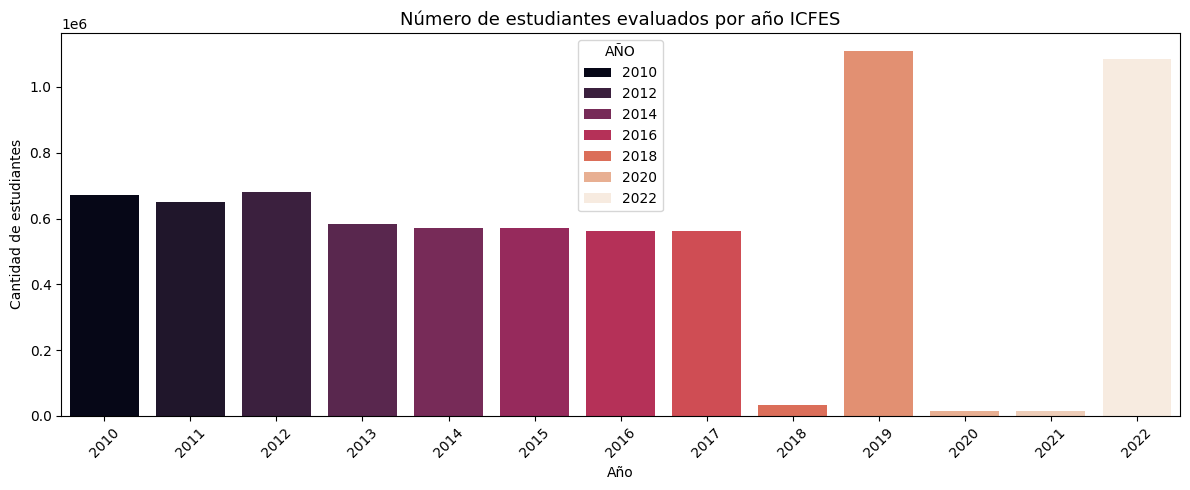

In [18]:
df_per = dfICFES3.groupBy("AÑO").count().orderBy("AÑO").toPandas()

plt.figure(figsize=(12,5))
sns.barplot(data=df_per, x="AÑO", y="count", hue = 'AÑO',palette="rocket")
plt.title("Número de estudiantes evaluados por año ICFES", fontsize=13)
plt.xlabel("Año")
plt.ylabel("Cantidad de estudiantes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se observa una variación en la cantidad de estudiantes que presentaron las pruebas Saber 11 a lo largo de los años analizados. En términos generales, la participación se mantiene alta y relativamente estable, lo que evidencia la continuidad del sistema de evaluación nacional. Las diferencias entre años pueden estar asociadas a cambios demográficos, cobertura educativa o situaciones extraordinarias como la pandemia.

La estabilidad en el volumen de registros permite realizar comparaciones históricas con mayor confiabilidad, ya que el conjunto de datos conserva representatividad temporal.

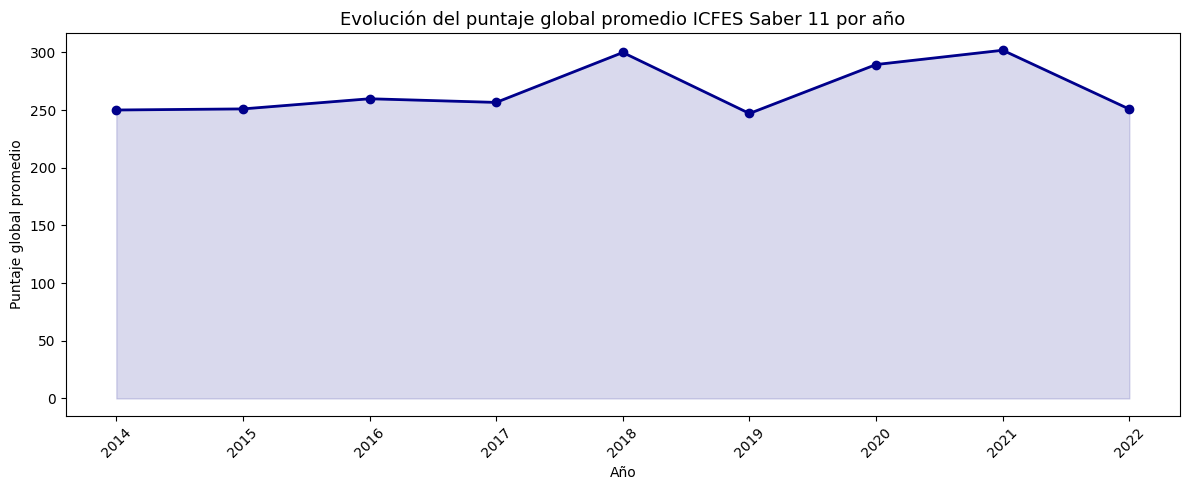

In [19]:
df_evol = dfICFES3.filter(col("PUNT_GLOBAL").isNotNull()) \
    .groupBy("AÑO") \
    .agg(F.avg("PUNT_GLOBAL").alias("PUNTAJE_PROM")) \
    .orderBy("AÑO").toPandas()

plt.figure(figsize=(12,5))
plt.plot(df_evol["AÑO"], df_evol["PUNTAJE_PROM"],
         marker="o", color="darkblue", linewidth=2)
plt.fill_between(df_evol["AÑO"], df_evol["PUNTAJE_PROM"], alpha=0.15, color="darkblue")
plt.title("Evolución del puntaje global promedio ICFES Saber 11 por año", fontsize=13)
plt.xlabel("Año")
plt.ylabel("Puntaje global promedio")
plt.xticks(df_evol["AÑO"], rotation=45)
plt.tight_layout()
plt.show()

El comportamiento del puntaje global promedio muestra una tendencia relativamente estable a través de los años, aunque pueden identificarse ligeras variaciones entre periodos. Esto sugiere que el rendimiento académico nacional no presenta cambios drásticos en el largo plazo, pero sí pequeñas fluctuaciones asociadas a factores sociales, económicos y educativos.
Las disminuciones observadas en ciertos años podrían relacionarse con desigualdades en acceso a recursos educativos, mientras que las mejoras pueden reflejar fortalecimiento institucional o avances tecnológicos en el sistema educativo.

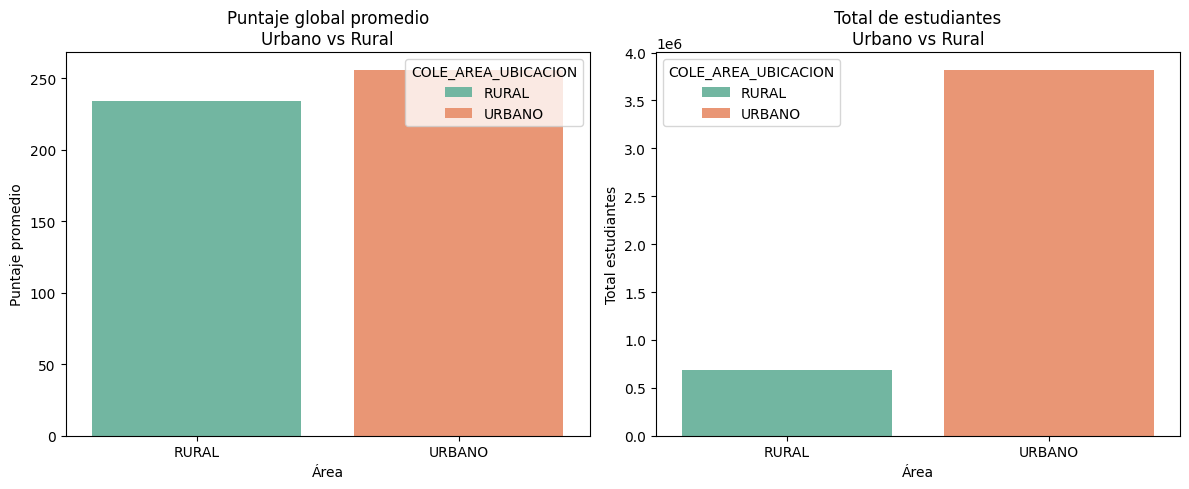

In [20]:
df_area = dfICFES2.filter(col("PUNT_GLOBAL").isNotNull()) \
    .groupBy("COLE_AREA_UBICACION") \
    .agg(F.avg("PUNT_GLOBAL").alias("PUNTAJE_PROM"),
         F.count("*").alias("TOTAL")) \
    .toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.barplot(data=df_area, x="COLE_AREA_UBICACION", y="PUNTAJE_PROM", hue = 'COLE_AREA_UBICACION',
            palette="Set2", ax=axes[0])
axes[0].set_title("Puntaje global promedio\nUrbano vs Rural")
axes[0].set_xlabel("Área")
axes[0].set_ylabel("Puntaje promedio")

sns.barplot(data=df_area, x="COLE_AREA_UBICACION", y="TOTAL", hue = 'COLE_AREA_UBICACION',
            palette="Set2", ax=axes[1])
axes[1].set_title("Total de estudiantes\nUrbano vs Rural")
axes[1].set_xlabel("Área")
axes[1].set_ylabel("Total estudiantes")

plt.tight_layout()
plt.show()

Los resultados evidencian diferencias importantes entre estudiantes de zonas urbanas y rurales. En general, los colegios ubicados en áreas urbanas presentan mayores puntajes promedio en comparación con los rurales, lo cual puede estar relacionado con una mayor disponibilidad de infraestructura, acceso a internet, docentes especializados y recursos educativos.
La brecha urbano-rural continúa siendo un desafío estructural dentro del sistema educativo colombiano y refleja desigualdades en oportunidades de aprendizaje.

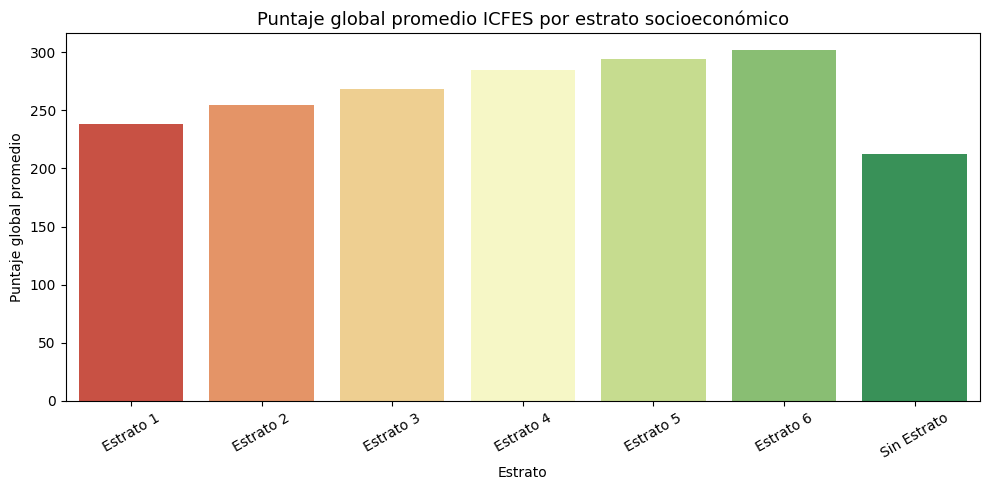

In [21]:
df_estrato = dfICFES2.filter(
    col("PUNT_GLOBAL").isNotNull() & col("FAMI_ESTRATOVIVIENDA").isNotNull()) \
    .groupBy("FAMI_ESTRATOVIVIENDA") \
    .agg(F.avg("PUNT_GLOBAL").alias("PUNTAJE_PROM")) \
    .orderBy("FAMI_ESTRATOVIVIENDA").toPandas()

plt.figure(figsize=(10,5))
sns.barplot(data=df_estrato, x="FAMI_ESTRATOVIVIENDA", y="PUNTAJE_PROM", hue = 'FAMI_ESTRATOVIVIENDA', palette="RdYlGn")
plt.title("Puntaje global promedio ICFES por estrato socioeconómico", fontsize=13)
plt.xlabel("Estrato")
plt.ylabel("Puntaje global promedio")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Existe una relación positiva entre el estrato socioeconómico y el desempeño académico. A medida que aumenta el estrato, también tiende a incrementarse el puntaje global promedio de los estudiantes.
Este comportamiento evidencia cómo las condiciones económicas del hogar influyen en el acceso a herramientas educativas, acompañamiento académico y estabilidad social, factores que impactan directamente el rendimiento escolar.

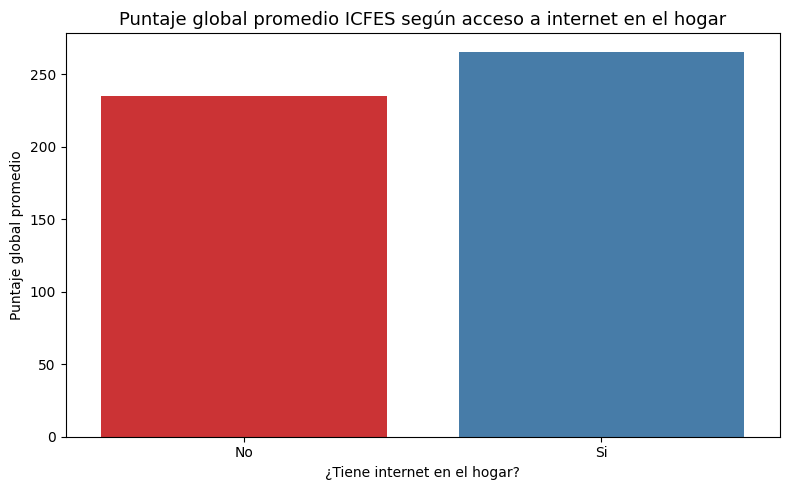

In [22]:
df_inet = dfICFES2.filter(
    col("PUNT_GLOBAL").isNotNull() & col("FAMI_TIENEINTERNET").isNotNull()) \
    .groupBy("FAMI_TIENEINTERNET") \
    .agg(F.avg("PUNT_GLOBAL").alias("PUNTAJE_PROM"),
         F.count("*").alias("TOTAL")) \
    .toPandas()

plt.figure(figsize=(8,5))
sns.barplot(data=df_inet, x="FAMI_TIENEINTERNET", y="PUNTAJE_PROM", hue = 'FAMI_TIENEINTERNET', palette="Set1")
plt.title("Puntaje global promedio ICFES según acceso a internet en el hogar", fontsize=13)
plt.xlabel("¿Tiene internet en el hogar?")
plt.ylabel("Puntaje global promedio")
plt.tight_layout()
plt.show()

Los estudiantes que cuentan con acceso a internet en sus hogares presentan, en promedio, mejores resultados en las pruebas Saber 11. Esto sugiere que la conectividad representa un factor importante en el acceso al conocimiento, plataformas educativas y herramientas de apoyo académico.

La diferencia observada reafirma la relevancia de reducir la brecha digital como estrategia para mejorar la equidad educativa.

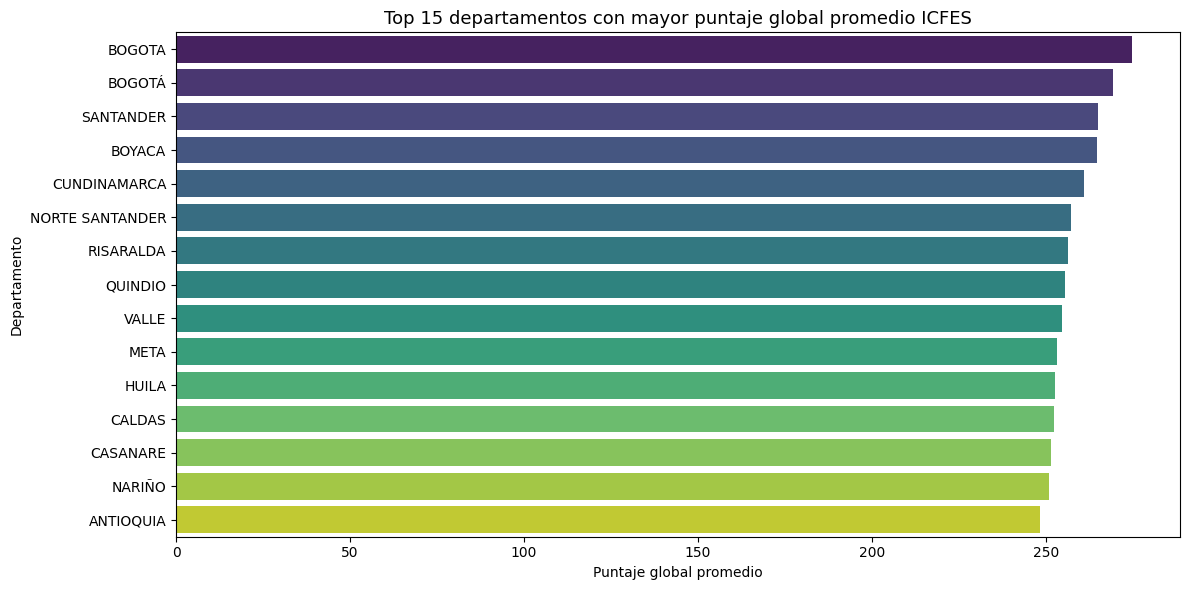

In [23]:
df_depto_punt = dfICFES3.filter(col("PUNT_GLOBAL").isNotNull()) \
    .groupBy("COLE_DEPTO_UBICACION") \
    .agg(F.avg("PUNT_GLOBAL").alias("PUNTAJE_PROM")) \
    .orderBy("PUNTAJE_PROM", ascending=False).limit(15).toPandas()

plt.figure(figsize=(12,6))
sns.barplot(data=df_depto_punt, x="PUNTAJE_PROM", y="COLE_DEPTO_UBICACION",
            hue="COLE_DEPTO_UBICACION", palette="viridis", legend=False)
plt.title("Top 15 departamentos con mayor puntaje global promedio ICFES", fontsize=13)
plt.xlabel("Puntaje global promedio")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()

Los departamentos con mejores puntajes promedio corresponden, en su mayoría, a regiones con mayor desarrollo económico y mejores indicadores de infraestructura educativa. Esto refleja diferencias territoriales importantes en calidad educativa.

La concentración de mejores resultados en ciertos departamentos sugiere desigualdades regionales que podrían abordarse mediante políticas públicas focalizadas.

In [24]:
from pyspark.sql.functions import avg
import pandas as pd

promedios = pd.DataFrame({
    "Área": [
        "Lectura Crítica",
        "Matemáticas",
        "Sociales",
        "Ciencias Naturales",
        "Inglés",
        "Global"
    ],

    "Puntaje Promedio": [

        dfICFES.select(avg("punt_lectura_critica")).collect()[0][0],

        dfICFES.select(avg("punt_matematicas")).collect()[0][0],

        dfICFES.select(avg("punt_sociales_ciudadanas")).collect()[0][0],

        dfICFES.select(avg("punt_c_naturales")).collect()[0][0],

        dfICFES.select(avg("punt_ingles")).collect()[0][0],

        dfICFES.select(avg("punt_global")).collect()[0][0]
    ]
})

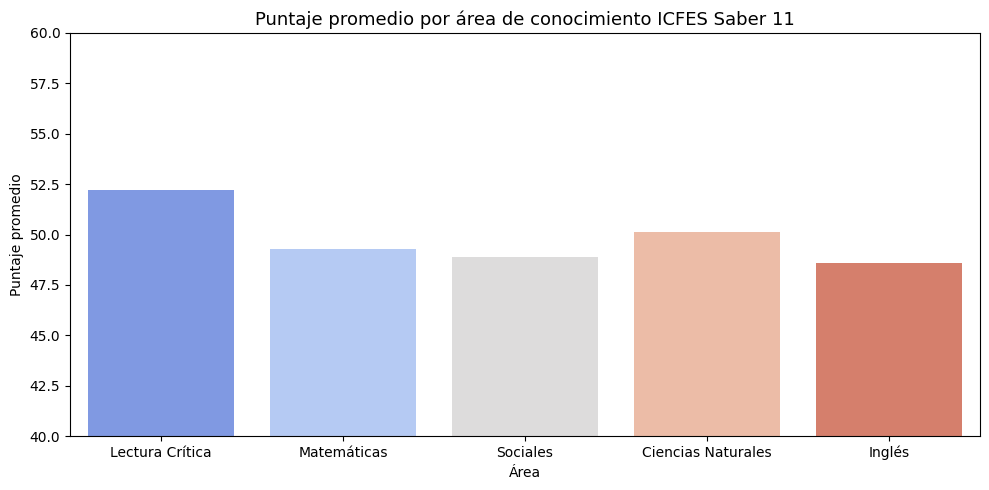

In [25]:
promedios_sin_global = promedios[promedios["Área"] != "Global"]

plt.figure(figsize=(10,5))

sns.barplot(
    data=promedios_sin_global,
    x="Área",
    y="Puntaje Promedio",
    hue="Área",
    palette="coolwarm",
    legend=False
)

plt.title("Puntaje promedio por área de conocimiento ICFES Saber 11", fontsize=13)
plt.xlabel("Área")
plt.ylabel("Puntaje promedio")
plt.ylim(40, 60)
plt.tight_layout()
plt.show()

Las distintas áreas evaluadas presentan diferencias en sus puntajes promedio. Algunas asignaturas muestran desempeños más sólidos, como lo es la lectura critica, mientras que otras reflejan mayores dificultades académicas para los estudiantes, como ingles.
El análisis por áreas permite identificar fortalezas y debilidades específicas del sistema educativo, facilitando la definición de estrategias pedagógicas focalizadas.

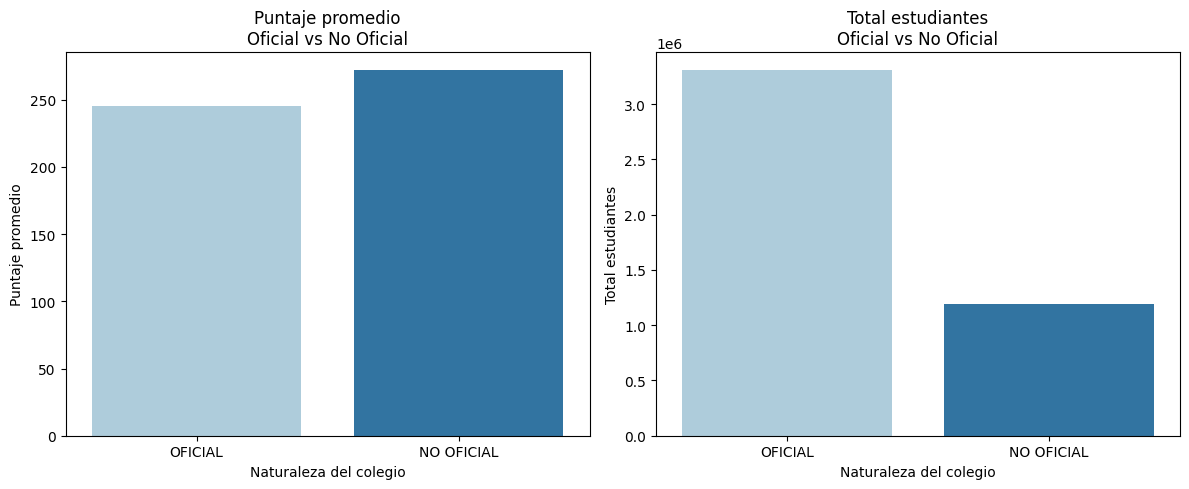

In [26]:
df_nat = dfICFES3.filter(
    col("PUNT_GLOBAL").isNotNull() & col("COLE_NATURALEZA").isNotNull()) \
    .groupBy("COLE_NATURALEZA") \
    .agg(F.avg("PUNT_GLOBAL").alias("PUNTAJE_PROM"),
         F.count("*").alias("TOTAL")).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.barplot(data=df_nat, x="COLE_NATURALEZA", y="PUNTAJE_PROM",
            hue="COLE_NATURALEZA", palette="Paired", legend=False, ax=axes[0])
axes[0].set_title("Puntaje promedio\nOficial vs No Oficial")
axes[0].set_xlabel("Naturaleza del colegio")
axes[0].set_ylabel("Puntaje promedio")

sns.barplot(data=df_nat, x="COLE_NATURALEZA", y="TOTAL",
            hue="COLE_NATURALEZA", palette="Paired", legend=False, ax=axes[1])
axes[1].set_title("Total estudiantes\nOficial vs No Oficial")
axes[1].set_xlabel("Naturaleza del colegio")
axes[1].set_ylabel("Total estudiantes")
plt.tight_layout()
plt.show()

Se observan diferencias entre instituciones oficiales y privadas en el puntaje promedio obtenido por los estudiantes. Generalmente, los colegios privados alcanzan resultados superiores, posiblemente debido a mayores recursos institucionales, menor número de estudiantes por aula y acceso a tecnologías educativas.

Aunque existen excepciones, los resultados evidencian desigualdades estructurales en las condiciones de enseñanza entre ambos tipos de instituciones.

# Dataset 2

In [27]:
# Ver esquema
dfInternet.printSchema()

root
 |-- AÑO: string (nullable = true)
 |-- TRIMESTRE: string (nullable = true)
 |-- PROVEEDOR: string (nullable = true)
 |-- COD_DEPARTAMENTO: string (nullable = true)
 |-- DEPARTAMENTO: string (nullable = true)
 |-- COD_MUNICIPIO: string (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- SEGMENTO: string (nullable = true)
 |-- TECNOLOGIA: string (nullable = true)
 |-- VELOCIDAD_BAJADA: string (nullable = true)
 |-- VELOCIDAD_SUBIDA: string (nullable = true)
 |-- No DE ACCESOS: string (nullable = true)



In [28]:
def mostrar_tabla(df_spark, n=20):
    return df_spark.limit(n).toPandas()

In [29]:
# Contar registros totales
print("Total de registros:", dfInternet.count())

Total de registros: 2795052


In [30]:
# Estadísticos descriptivos
mostrar_tabla(dfInternet.describe())

,summary,AÑO,TRIMESTRE,PROVEEDOR,COD_DEPARTAMENTO,DEPARTAMENTO,COD_MUNICIPIO,MUNICIPIO,SEGMENTO,TECNOLOGIA,VELOCIDAD_BAJADA,VELOCIDAD_SUBIDA,No DE ACCESOS
0,count,2795052,2795052,2795052,2795047,2795052,2795042,2795052,2795052,2795052,2795052,2795052,2795052
1,mean,2020.9017853692883,2.4440740279608395,None,37.26432149441494,None,37581.22693433587,None,None,None,None,None,71.94877912825952
2,stddev,1.8256186868652533,1.0764098853182646,None,26.657713047841323,None,26640.23749791105,None,None,None,None,None,949.8050977506256
3,min,2016,1,"""AIRWEB TELECOMUNICACIONES SAS """"ZOMAC""""""",05,AMAZONAS,05001,ABEJORRAL,CORPORATIVO,CABLE,"0,00","0,00",0
4,max,2023,4,ZUMA COMUNICACIONES DE COLOMBIA S.A.S,99,VICHADA,99773,ÚTICA,USO PROPIO INTERNO DEL OPERADOR,XDSL,"999,00","9999,00",9995


El dataset presenta un volumen considerable de registros, lo que permite realizar análisis representativos sobre el acceso a internet fijo en Colombia. Los estadísticos descriptivos muestran una amplia variabilidad en la cantidad de accesos y velocidades de conexión.
La diversidad de valores evidencia diferencias significativas entre municipios, tecnologías y segmentos del mercado.

In [31]:
from pyspark.sql.functions import col, when, isnull, sum as Fsum
import pyspark.sql.functions as F

# ── 1. Castear columnas numéricas
dfInternet2 = dfInternet \
    .withColumn("VELOCIDAD_BAJADA_NUM",
                F.regexp_replace(col("VELOCIDAD_BAJADA"), ",", ".").cast("double")) \
    .withColumn("VELOCIDAD_SUBIDA_NUM",
                F.regexp_replace(col("VELOCIDAD_SUBIDA"), ",", ".").cast("double")) \
    .withColumn("ACCESOS_NUM",
                F.regexp_replace(col("No DE ACCESOS"), ",", "").cast("integer"))

dfInternet2.printSchema()

root
 |-- AÑO: string (nullable = true)
 |-- TRIMESTRE: string (nullable = true)
 |-- PROVEEDOR: string (nullable = true)
 |-- COD_DEPARTAMENTO: string (nullable = true)
 |-- DEPARTAMENTO: string (nullable = true)
 |-- COD_MUNICIPIO: string (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- SEGMENTO: string (nullable = true)
 |-- TECNOLOGIA: string (nullable = true)
 |-- VELOCIDAD_BAJADA: string (nullable = true)
 |-- VELOCIDAD_SUBIDA: string (nullable = true)
 |-- No DE ACCESOS: string (nullable = true)
 |-- VELOCIDAD_BAJADA_NUM: double (nullable = true)
 |-- VELOCIDAD_SUBIDA_NUM: double (nullable = true)
 |-- ACCESOS_NUM: integer (nullable = true)



In [32]:
# ── 2. Valores nulos por columna
print("=== NULOS POR COLUMNA ===")
mostrar_tabla(dfInternet2.select([
    Fsum(when(isnull(c), 1).otherwise(0)).alias(c)
    for c in dfInternet2.columns
]))

=== NULOS POR COLUMNA ===


,AÑO,TRIMESTRE,PROVEEDOR,COD_DEPARTAMENTO,DEPARTAMENTO,COD_MUNICIPIO,MUNICIPIO,SEGMENTO,TECNOLOGIA,VELOCIDAD_BAJADA,VELOCIDAD_SUBIDA,No DE ACCESOS,VELOCIDAD_BAJADA_NUM,VELOCIDAD_SUBIDA_NUM,ACCESOS_NUM
0,0,0,0,5,0,10,0,0,0,0,0,0,0,0,0


El análisis de valores nulos permitió identificar columnas con información incompleta, lo cual hizo necesario aplicar procesos de limpieza y filtrado para garantizar la calidad del análisis.
La reducción de datos faltantes mejora la confiabilidad de los resultados y evita sesgos estadísticos.

In [33]:
# ── 3. Distribución por año
print("REGISTROS POR AÑO")
mostrar_tabla(dfInternet2.groupBy("AÑO").count().orderBy("AÑO"))

REGISTROS POR AÑO


,AÑO,count
0,2016,56
1,2017,156886
2,2018,233772
3,2019,293282
4,2020,342123
5,2021,399848
6,2022,754858
7,2023,614227


In [34]:

# ── 4. Distribución por tecnología
print("=== REGISTROS POR TECNOLOGÍA ===")
mostrar_tabla(dfInternet2.groupBy("TECNOLOGIA").count().orderBy("count", ascending=False))

=== REGISTROS POR TECNOLOGÍA ===


,TECNOLOGIA,count
0,CABLE,639283
1,FIBER TO THE HOME (FTTH),630091
2,XDSL,510367
3,OTRAS TECNOLOGÍAS INALÁMBRICAS,280690
4,HYBRID FIBER COAXIAL (HFC),212051
5,SATELITAL,174319
6,OTRAS TECNOLOGÍAS DE FIBRA (ANTES FTTX),156455
7,WIFI,110824
8,FIBER TO THE BUILDING O FIBER TO THE BASEMENT ...,20035
9,FIBER TO THE CABINET (FTTC),19992


In [35]:
# ── 5. Distribución por segmento
print("=== REGISTROS POR SEGMENTO ===")
mostrar_tabla(dfInternet2.groupBy("SEGMENTO").count().orderBy("count", ascending=False))

=== REGISTROS POR SEGMENTO ===


,SEGMENTO,count
0,CORPORATIVO,893577
1,RESIDENCIAL - ESTRATO 2,594438
2,RESIDENCIAL - ESTRATO 3,423739
3,RESIDENCIAL - ESTRATO 1,418236
4,RESIDENCIAL - ESTRATO 4,224848
5,RESIDENCIAL - ESTRATO 5,109898
6,RESIDENCIAL - ESTRATO 6,85552
7,SIN ESTRATIFICAR,38396
8,USO PROPIO INTERNO DEL OPERADOR,6368


In [36]:
# ── 6. Top 10 departamentos con más accesos
print(" TOP 10 DEPARTAMENTOS ")
mostrar_tabla(dfInternet2.groupBy("DEPARTAMENTO") \
    .agg(Fsum("ACCESOS_NUM").alias("TOTAL_ACCESOS")) \
    .orderBy("TOTAL_ACCESOS", ascending=False))

 TOP 10 DEPARTAMENTOS 


,DEPARTAMENTO,TOTAL_ACCESOS
0,BOGOTÁ D.C.,53957365
1,ANTIOQUIA,35342014
2,VALLE DEL CAUCA,21783112
3,CUNDINAMARCA,12850353
4,ATLÁNTICO,10366668
5,SANTANDER,9668325
6,BOLÍVAR,5551870
7,RISARALDA,5059700
8,TOLIMA,4697547
9,NORTE DE SANTANDER,4364663


In [37]:
por_anio = dfInternet2.groupBy("AÑO").count().orderBy("AÑO")
mostrar_tabla(por_anio)

,AÑO,count
0,2016,56
1,2017,156886
2,2018,233772
3,2019,293282
4,2020,342123
5,2021,399848
6,2022,754858
7,2023,614227


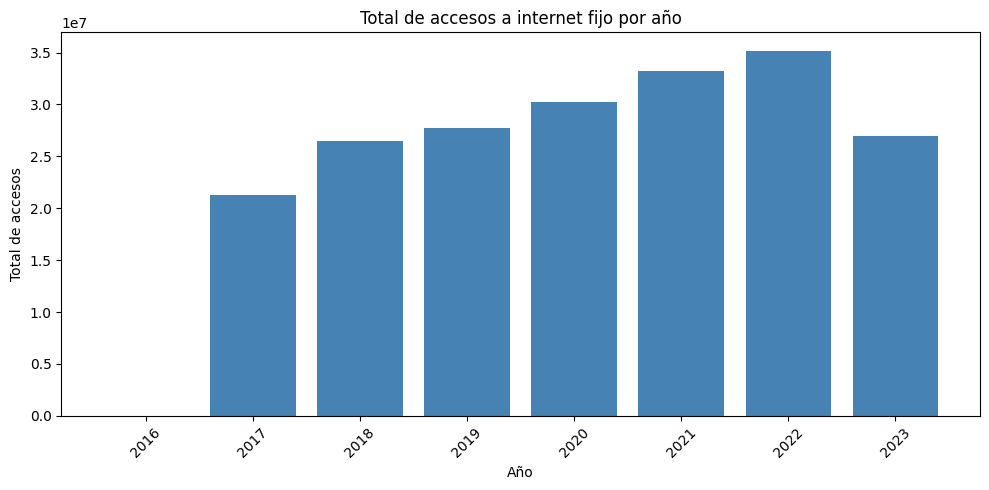

In [38]:
df_anio = dfInternet2.groupBy("AÑO") \
    .agg(Fsum("ACCESOS_NUM").alias("TOTAL_ACCESOS")) \
    .orderBy("AÑO").toPandas()

plt.figure(figsize=(10,5))
plt.bar(df_anio["AÑO"], df_anio["TOTAL_ACCESOS"], color="steelblue")
plt.title("Total de accesos a internet fijo por año")
plt.xlabel("Año")
plt.ylabel("Total de accesos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

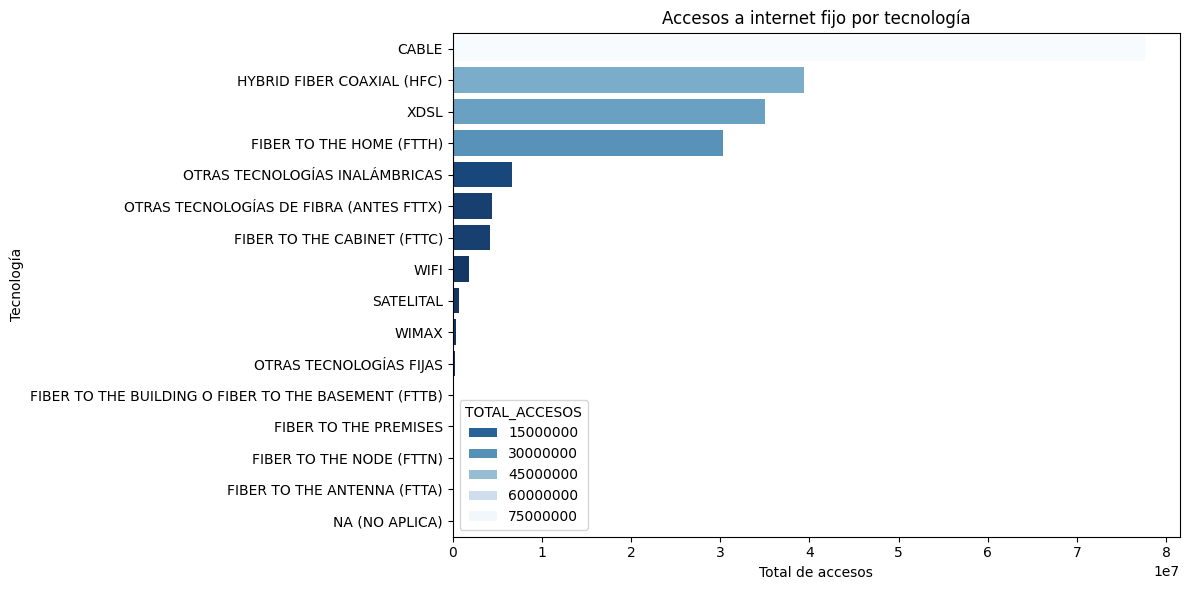

In [39]:
df_tec = dfInternet2.groupBy("TECNOLOGIA") \
    .agg(Fsum("ACCESOS_NUM").alias("TOTAL_ACCESOS")) \
    .orderBy("TOTAL_ACCESOS", ascending=False).toPandas()

plt.figure(figsize=(12,6))
sns.barplot(data=df_tec, x="TOTAL_ACCESOS", y="TECNOLOGIA", hue = 'TOTAL_ACCESOS', palette="Blues_r")
plt.title("Accesos a internet fijo por tecnología")
plt.xlabel("Total de accesos")
plt.ylabel("Tecnología")
plt.tight_layout()
plt.show()

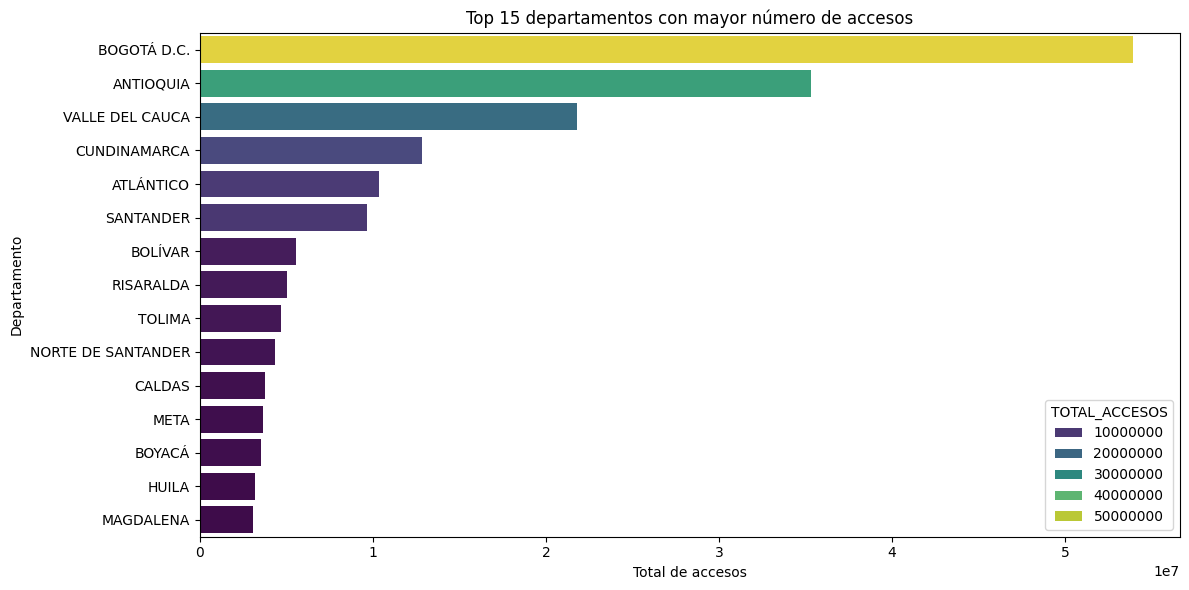

In [40]:
df_depto = dfInternet2.groupBy("DEPARTAMENTO") \
    .agg(Fsum("ACCESOS_NUM").alias("TOTAL_ACCESOS")) \
    .orderBy("TOTAL_ACCESOS", ascending=False).limit(15).toPandas()

plt.figure(figsize=(12,6))
sns.barplot(data=df_depto, x="TOTAL_ACCESOS", y="DEPARTAMENTO", hue = 'TOTAL_ACCESOS', palette="viridis")
plt.title("Top 15 departamentos con mayor número de accesos")
plt.xlabel("Total de accesos")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()

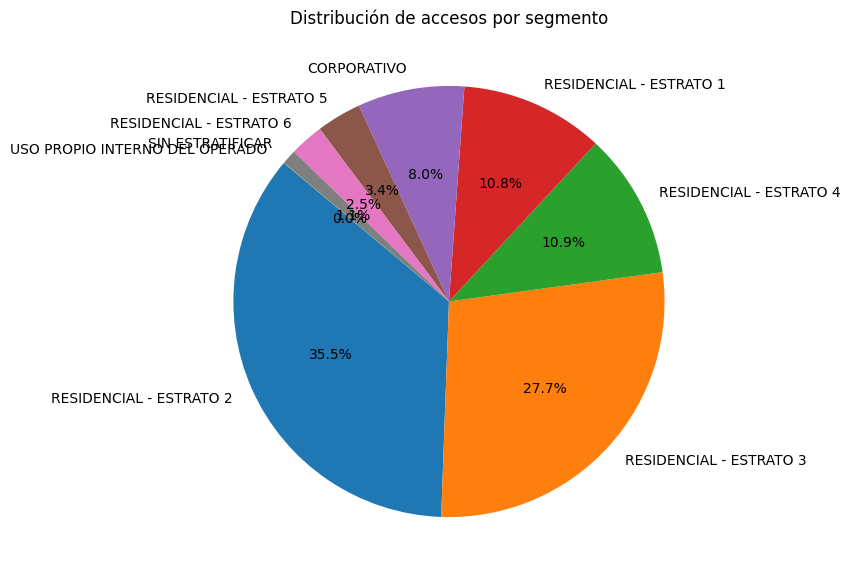

In [41]:
df_seg = dfInternet2.groupBy("SEGMENTO") \
    .agg(Fsum("ACCESOS_NUM").alias("TOTAL_ACCESOS")) \
    .orderBy("TOTAL_ACCESOS", ascending=False).toPandas()

# Limpiar nombres truncados
df_seg["SEGMENTO"] = df_seg["SEGMENTO"].str[:30]

plt.figure(figsize=(10,7))
plt.pie(df_seg["TOTAL_ACCESOS"], labels=df_seg["SEGMENTO"],
        autopct="%1.1f%%", startangle=140)
plt.title("Distribución de accesos por segmento")

plt.show()

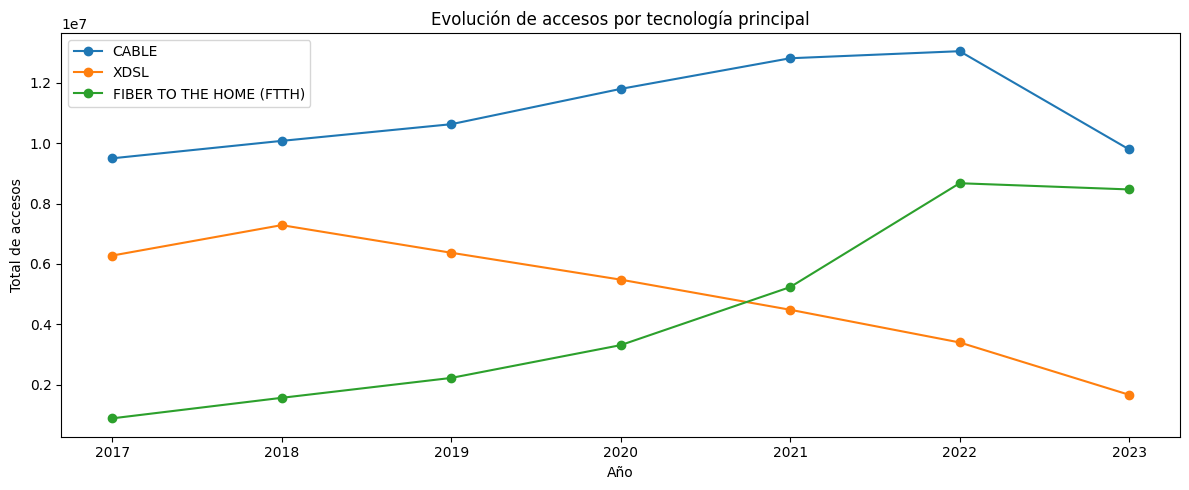

In [42]:
tecnologias_top = ["CABLE", "FIBER TO THE HOME...", "XDSL"]

df_evol = dfInternet2.filter(col("TECNOLOGIA").isin(
    ["CABLE","FIBER TO THE HOME (FTTH)","XDSL"])) \
    .groupBy("AÑO","TECNOLOGIA") \
    .agg(Fsum("ACCESOS_NUM").alias("TOTAL_ACCESOS")) \
    .orderBy("AÑO").toPandas()

plt.figure(figsize=(12,5))
for tec in df_evol["TECNOLOGIA"].unique():
    subset = df_evol[df_evol["TECNOLOGIA"]==tec]
    plt.plot(subset["AÑO"], subset["TOTAL_ACCESOS"], marker="o", label=tec)

plt.title("Evolución de accesos por tecnología principal")
plt.xlabel("Año")
plt.ylabel("Total de accesos")
plt.legend()
plt.tight_layout()
plt.show()

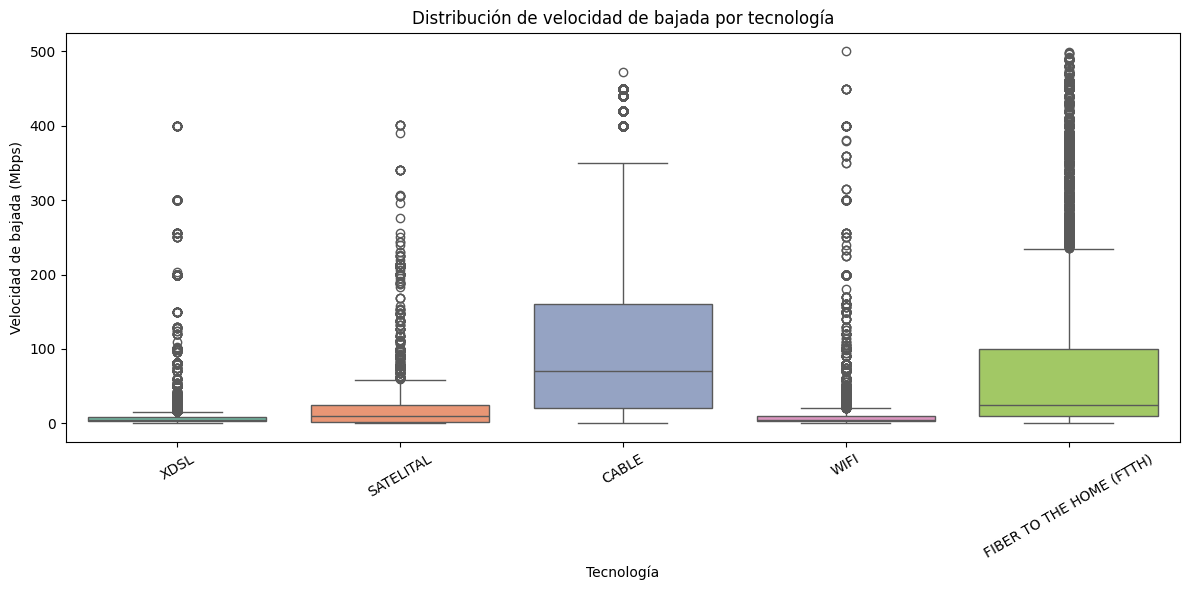

In [43]:
df_vel = dfInternet2.select("TECNOLOGIA","VELOCIDAD_BAJADA_NUM") \
    .filter(col("VELOCIDAD_BAJADA_NUM") < 500) \
    .filter(col("TECNOLOGIA").isin(["CABLE","XDSL","FIBER TO THE HOME (FTTH)","WIFI","SATELITAL"])) \
    .toPandas()

plt.figure(figsize=(12,6))
sns.boxplot(data=df_vel, x="TECNOLOGIA", y="VELOCIDAD_BAJADA_NUM", hue = 'TECNOLOGIA', palette="Set2")
plt.title("Distribución de velocidad de bajada por tecnología")
plt.xlabel("Tecnología")
plt.ylabel("Velocidad de bajada (Mbps)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [44]:
# ── Filtros internet: quitar nulos y año 2016 incompleto (Entrega 1) ──
dfInternet_clean = dfInternet2 \
    .filter(col("COD_MUNICIPIO").isNotNull()) \
    .filter(col("COD_DEPARTAMENTO").isNotNull()) \
    .filter(col("AÑO") != "2016") \
    .filter(col("ACCESOS_NUM").isNotNull())

print("Registros originales:", dfInternet2.count())
print("Registros después de filtros:", dfInternet_clean.count())

Registros originales: 2795052


[Stage 158:==========================================>             (9 + 3) / 12]

Registros después de filtros: 2794987


In [45]:
# ── Acumulado anual de accesos por municipio (Entrega 1) ──
dfInternet_mcpio = dfInternet_clean \
    .groupBy("AÑO", "COD_MUNICIPIO", "MUNICIPIO", "COD_DEPARTAMENTO", "DEPARTAMENTO") \
    .agg(Fsum("ACCESOS_NUM").alias("TOTAL_ACCESOS"))

print("Municipios únicos con datos de internet:")
dfInternet_mcpio.select("COD_MUNICIPIO").distinct().count()

Municipios únicos con datos de internet:


1120

# DATASET 3 — Indicadores Educativos

In [46]:
# ── Limpieza de porcentajes, comas y casteo
cols_pct = [
    "TASA_MATRICULACIÓN_5_16", "COBERTURA_NETA", "COBERTURA_NETA_TRANSICIÓN",
    "COBERTURA_NETA_PRIMARIA", "COBERTURA_NETA_SECUNDARIA", "COBERTURA_NETA_MEDIA",
    "COBERTURA_BRUTA", "COBERTURA_BRUTA_TRANSICIÓN", "COBERTURA_BRUTA_PRIMARIA",
    "COBERTURA_BRUTA_SECUNDARIA", "COBERTURA_BRUTA_MEDIA",
    "DESERCIÓN", "DESERCIÓN_TRANSICIÓN", "DESERCIÓN_PRIMARIA",
    "DESERCIÓN_SECUNDARIA", "DESERCIÓN_MEDIA",
    "APROBACIÓN", "APROBACIÓN_TRANSICIÓN", "APROBACIÓN_PRIMARIA",
    "APROBACIÓN_SECUNDARIA", "APROBACIÓN_MEDIA",
    "REPROBACIÓN", "REPROBACIÓN_TRANSICIÓN", "REPROBACIÓN_PRIMARIA",
    "REPROBACIÓN_SECUNDARIA", "REPROBACIÓN_MEDIA",
    "REPITENCIA", "REPITENCIA_TRANSICIÓN", "REPITENCIA_PRIMARIA",
    "REPITENCIA_SECUNDARIA", "REPITENCIA_MEDIA"
]

cols_num = ["POBLACIÓN_5_16", "TAMAÑO_PROMEDIO_DE_GRUPO", "SEDES_CONECTADAS_A_INTERNET"]

dfEdu2 = dfEducacion
for c in cols_pct:
    dfEdu2 = dfEdu2.withColumn(c,
        regexp_replace(regexp_replace(col(c), "%", ""), ",", ".").cast("double"))

for c in cols_num:
    dfEdu2 = dfEdu2.withColumn(c,
        regexp_replace(col(c), ",", "").cast("double"))

dfEdu2 = dfEdu2.withColumn("AÑO", col("AÑO").cast("integer"))

print("Schema limpio:")
dfEdu2.printSchema()

Schema limpio:
root
 |-- AÑO: integer (nullable = true)
 |-- CÓDIGO_MUNICIPIO: string (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- CÓDIGO_DEPARTAMENTO: string (nullable = true)
 |-- DEPARTAMENTO: string (nullable = true)
 |-- CÓDIGO_ETC: string (nullable = true)
 |-- ETC: string (nullable = true)
 |-- POBLACIÓN_5_16: double (nullable = true)
 |-- TASA_MATRICULACIÓN_5_16: double (nullable = true)
 |-- COBERTURA_NETA: double (nullable = true)
 |-- COBERTURA_NETA_TRANSICIÓN: double (nullable = true)
 |-- COBERTURA_NETA_PRIMARIA: double (nullable = true)
 |-- COBERTURA_NETA_SECUNDARIA: double (nullable = true)
 |-- COBERTURA_NETA_MEDIA: double (nullable = true)
 |-- COBERTURA_BRUTA: double (nullable = true)
 |-- COBERTURA_BRUTA_TRANSICIÓN: double (nullable = true)
 |-- COBERTURA_BRUTA_PRIMARIA: double (nullable = true)
 |-- COBERTURA_BRUTA_SECUNDARIA: double (nullable = true)
 |-- COBERTURA_BRUTA_MEDIA: double (nullable = true)
 |-- TAMAÑO_PROMEDIO_DE_GRUPO: double (null

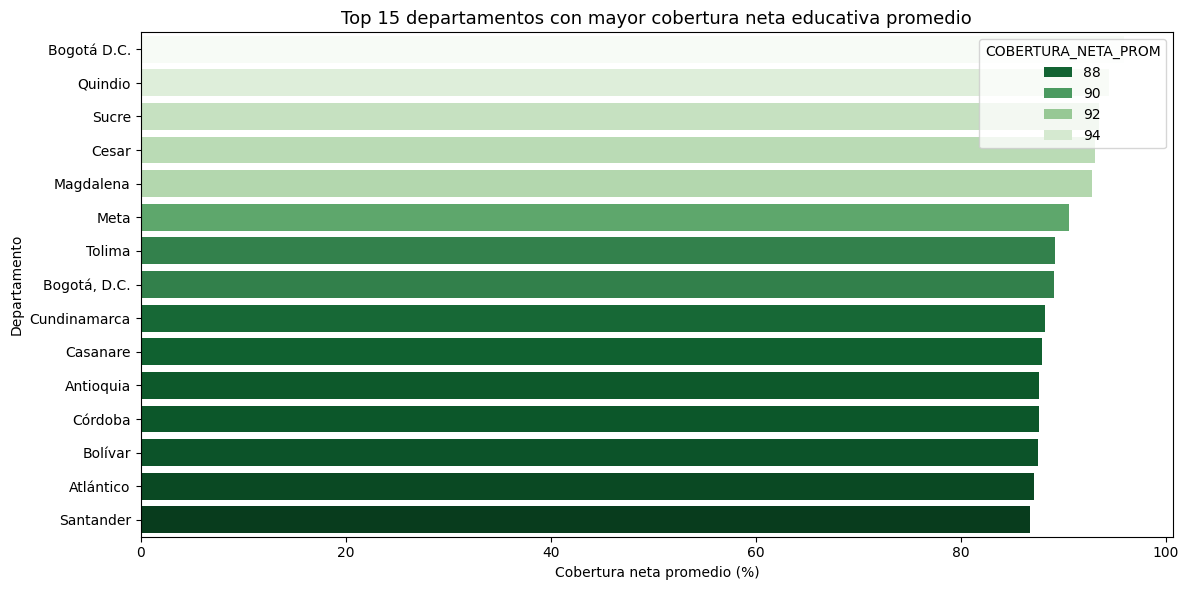

In [47]:
df_cob = dfEdu2.groupBy("DEPARTAMENTO") \
    .agg(F.avg("COBERTURA_NETA").alias("COBERTURA_NETA_PROM")) \
    .orderBy("COBERTURA_NETA_PROM", ascending=False).limit(15).toPandas()

plt.figure(figsize=(12,6))
sns.barplot(data=df_cob, x="COBERTURA_NETA_PROM", y="DEPARTAMENTO", hue = 'COBERTURA_NETA_PROM', palette="Greens_r")
plt.title("Top 15 departamentos con mayor cobertura neta educativa promedio", fontsize=13)
plt.xlabel("Cobertura neta promedio (%)")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()

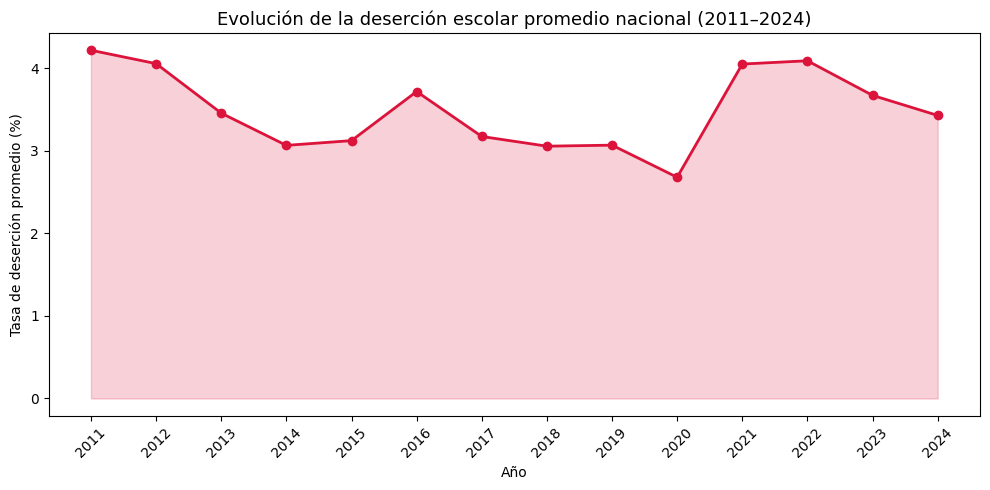

In [48]:
df_des = dfEdu2.groupBy("AÑO") \
    .agg(F.avg("DESERCIÓN").alias("DESERCIÓN_PROM")) \
    .orderBy("AÑO").toPandas()

plt.figure(figsize=(10,5))
plt.plot(df_des["AÑO"], df_des["DESERCIÓN_PROM"], marker="o", color="crimson", linewidth=2)
plt.fill_between(df_des["AÑO"], df_des["DESERCIÓN_PROM"], alpha=0.2, color="crimson")
plt.title("Evolución de la deserción escolar promedio nacional (2011–2024)", fontsize=13)
plt.xlabel("Año")
plt.ylabel("Tasa de deserción promedio (%)")
plt.xticks(df_des["AÑO"], rotation=45)
plt.tight_layout()
plt.show()

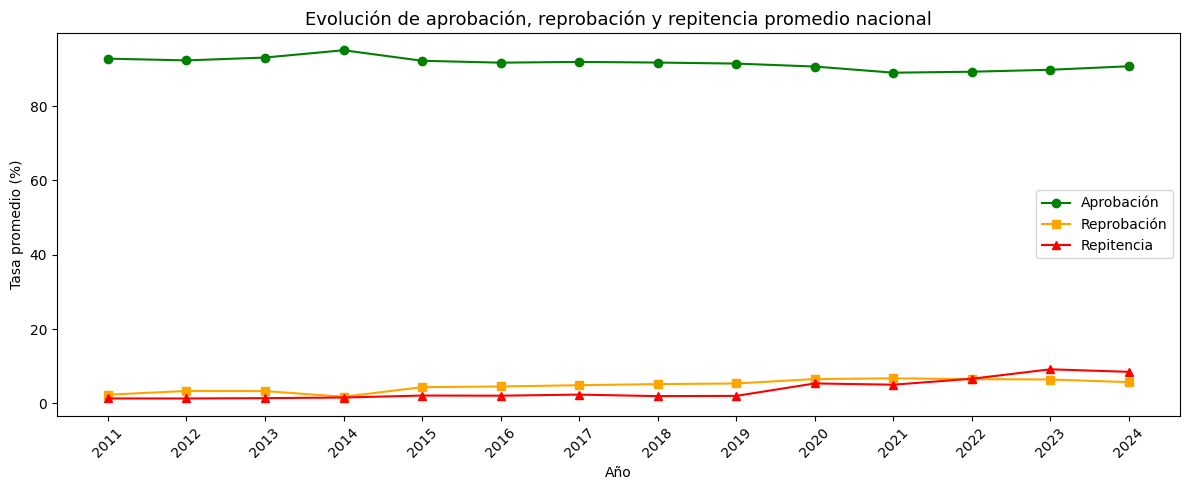

In [49]:
df_apr = dfEdu2.groupBy("AÑO").agg(
    F.avg("APROBACIÓN").alias("APROBACIÓN"),
    F.avg("REPROBACIÓN").alias("REPROBACIÓN"),
    F.avg("REPITENCIA").alias("REPITENCIA")
).orderBy("AÑO").toPandas()

plt.figure(figsize=(12,5))
plt.plot(df_apr["AÑO"], df_apr["APROBACIÓN"], marker="o", label="Aprobación", color="green")
plt.plot(df_apr["AÑO"], df_apr["REPROBACIÓN"], marker="s", label="Reprobación", color="orange")
plt.plot(df_apr["AÑO"], df_apr["REPITENCIA"], marker="^", label="Repitencia", color="red")
plt.title("Evolución de aprobación, reprobación y repitencia promedio nacional", fontsize=13)
plt.xlabel("Año")
plt.ylabel("Tasa promedio (%)")
plt.legend()
plt.xticks(df_apr["AÑO"], rotation=45)
plt.tight_layout()
plt.show()

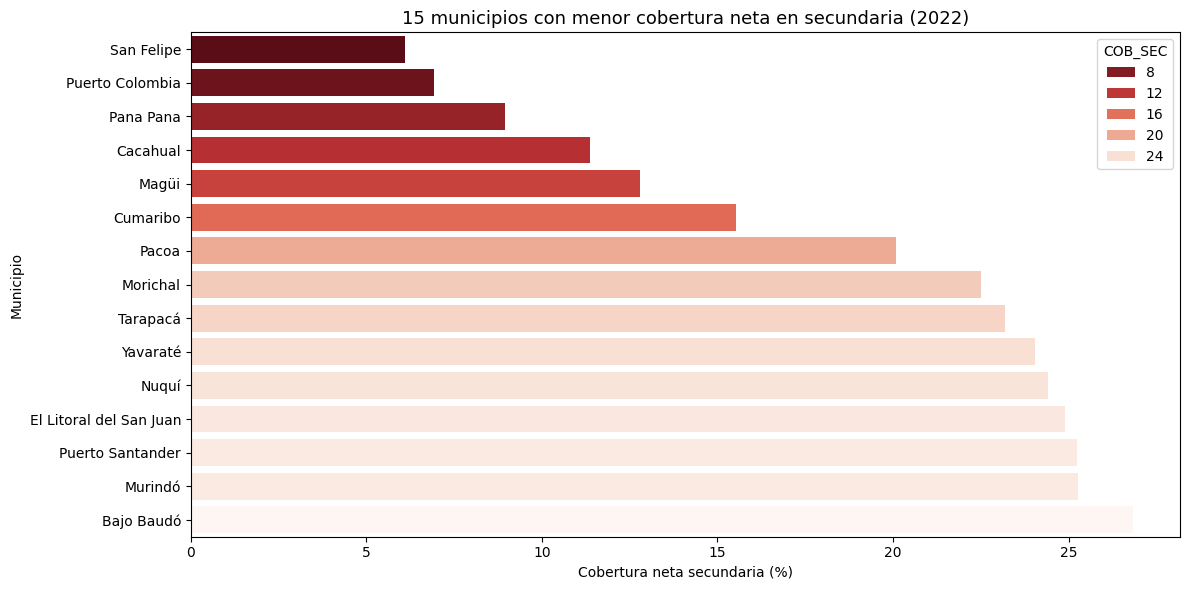

In [50]:
df_sec = dfEdu2.filter(col("AÑO") == 2022) \
    .groupBy("MUNICIPIO","DEPARTAMENTO") \
    .agg(F.avg("COBERTURA_NETA_SECUNDARIA").alias("COB_SEC")) \
    .filter(col("COB_SEC") > 0) \
    .orderBy("COB_SEC").limit(15).toPandas()

plt.figure(figsize=(12,6))
sns.barplot(data=df_sec, x="COB_SEC", y="MUNICIPIO", hue = 'COB_SEC',palette="Reds_r")
plt.title("15 municipios con menor cobertura neta en secundaria (2022)", fontsize=13)
plt.xlabel("Cobertura neta secundaria (%)")
plt.ylabel("Municipio")
plt.tight_layout()
plt.show()

In [51]:
# Ver cuántos nulos tiene cada columna de educación
from pyspark.sql.functions import isnull, when, sum as Fsum

cols_corr = [
    "COBERTURA_NETA", "COBERTURA_NETA_SECUNDARIA", "COBERTURA_NETA_MEDIA",
    "DESERCIÓN", "APROBACIÓN", "REPROBACIÓN", "REPITENCIA"
]

dfEdu2.select([
    Fsum(when(isnull(c), 1).otherwise(0)).alias(c)
    for c in cols_corr
]).toPandas()

,COBERTURA_NETA,COBERTURA_NETA_SECUNDARIA,COBERTURA_NETA_MEDIA,DESERCIÓN,APROBACIÓN,REPROBACIÓN,REPITENCIA
0,111,94,93,142,25,86,143


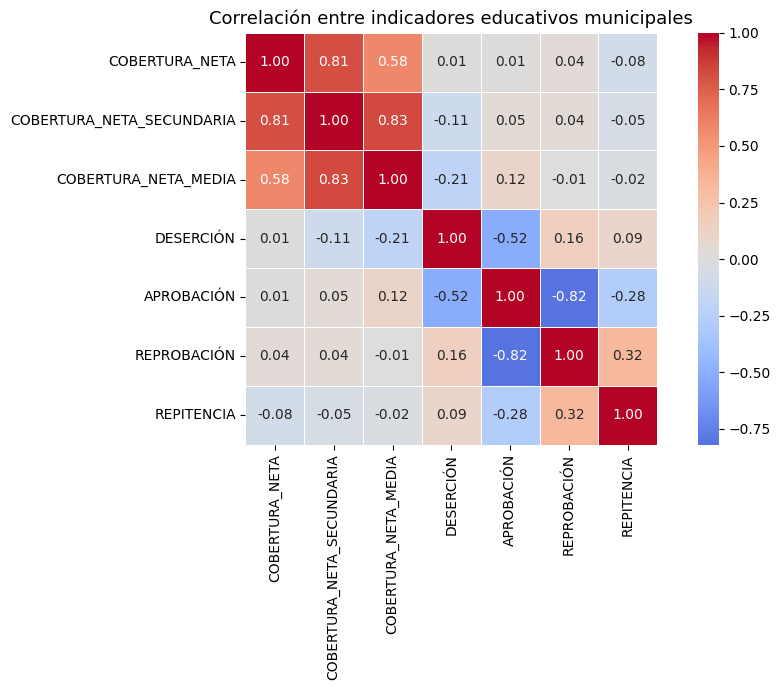

In [52]:
df_corr = dfEdu2.select(cols_corr).dropna().limit(50000).toPandas()

plt.figure(figsize=(10,7))
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True)
plt.title("Correlación entre indicadores educativos municipales", fontsize=13)
plt.tight_layout()
plt.show()

In [53]:
# ── Imputación de COBERTURA_NETA por mediana departamental ──
mediana_df = dfEdu2.groupBy("DEPARTAMENTO", "AÑO") \
    .agg(percentile_approx("COBERTURA_NETA", 0.5).alias("MEDIANA_COB"))

dfEdu_clean = dfEdu2.join(mediana_df, on=["DEPARTAMENTO", "AÑO"], how="left") \
    .withColumn("COBERTURA_NETA",
                when(col("COBERTURA_NETA").isNull(), col("MEDIANA_COB"))
                .otherwise(col("COBERTURA_NETA"))) \
    .drop("MEDIANA_COB")

print("Nulos restantes en COBERTURA_NETA:",
      dfEdu_clean.filter(col("COBERTURA_NETA").isNull()).count())

Nulos restantes en COBERTURA_NETA: 0


In [54]:
# Alias DESERCION sin tilde para compatibilidad con joins 
dfEdu_clean = dfEdu_clean.withColumn("DESERCION", col("DESERCIÓN"))

print("Nulos en DESERCION:", dfEdu_clean.filter(col("DESERCION").isNull()).count())

Nulos en DESERCION: 142


# DATASET 4 — Beneficiarios Estrategia UNIDOS

In [55]:
dfBeneficiarios.printSchema()
print("Total registros:", dfBeneficiarios.count())

root
 |-- CodigoFamilia: string (nullable = true)
 |-- TipoDocumento: string (nullable = true)
 |-- RangoEdad: string (nullable = true)
 |-- Pais: string (nullable = true)
 |-- CodigoDepartamentoAtencion: string (nullable = true)
 |-- NombreDepartamentoAtencion: string (nullable = true)
 |-- CodigoMunicipioAtencion: string (nullable = true)
 |-- NombreMunicipioAtencion: string (nullable = true)
 |-- PuntajeSISBEN: string (nullable = true)
 |-- BeneficiarioSISBEN: string (nullable = true)
 |-- CondicionSexual: string (nullable = true)
 |-- Discapacidad: string (nullable = true)
 |-- EstadoCivil: string (nullable = true)
 |-- Estrato: string (nullable = true)
 |-- Etnia: string (nullable = true)
 |-- Genero: string (nullable = true)
 |-- Parentesco: string (nullable = true)
 |-- TipoPoblacion: string (nullable = true)
 |-- EstadoBeneficiario: string (nullable = true)
 |-- Logro1: string (nullable = true)
 |-- Logro2: string (nullable = true)
 |-- Logro3: string (nullable = true)
 |-- Log

[Stage 203:=============================================>         (10 + 2) / 12]

Total registros: 1509751


In [56]:
from pyspark.sql.functions import isnull, when, sum as Fsum

# Solo columnas clave para no saturar
cols_key = [
    "CodigoFamilia", "TipoDocumento", "RangoEdad", "Pais",
    "CodigoDepartamentoAtencion", "NombreDepartamentoAtencion",
    "CodigoMunicipioAtencion", "NombreMunicipioAtencion",
    "PuntajeSISBEN", "BeneficiarioSISBEN", "CondicionSexual",
    "Discapacidad", "EstadoCivil", "Estrato", "Etnia", "Genero",
    "Parentesco", "TipoPoblacion", "EstadoBeneficiario"
]

dfBeneficiarios.select([
    Fsum(when(isnull(c), 1).otherwise(0)).alias(c)
    for c in cols_key
]).toPandas()

,CodigoFamilia,TipoDocumento,RangoEdad,Pais,CodigoDepartamentoAtencion,NombreDepartamentoAtencion,CodigoMunicipioAtencion,NombreMunicipioAtencion,PuntajeSISBEN,BeneficiarioSISBEN,CondicionSexual,Discapacidad,EstadoCivil,Estrato,Etnia,Genero,Parentesco,TipoPoblacion,EstadoBeneficiario
0,0,0,0,0,0,0,0,0,0,301195,0,0,0,0,0,0,0,0,0


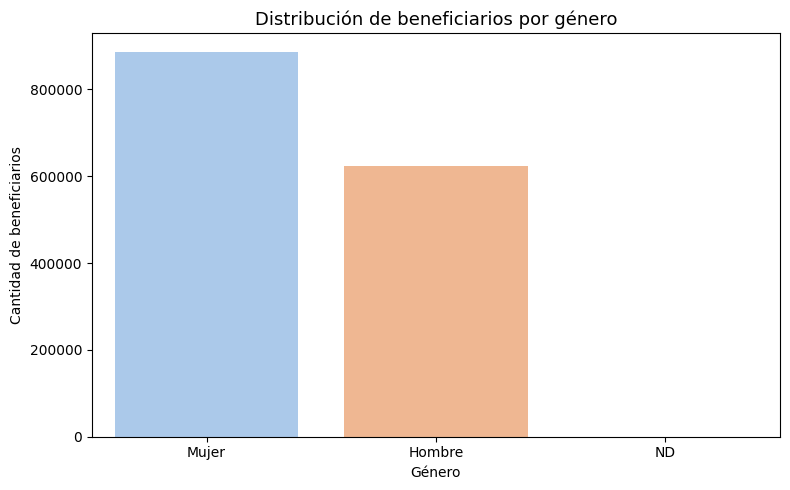

In [57]:
df_gen = dfBeneficiarios.groupBy("Genero").count().orderBy("count", ascending=False).toPandas()

plt.figure(figsize=(8,5))
sns.barplot(data=df_gen, x="Genero", y="count", hue = 'Genero' , palette="pastel")
plt.title("Distribución de beneficiarios por género", fontsize=13)
plt.xlabel("Género")
plt.ylabel("Cantidad de beneficiarios")
plt.tight_layout()
plt.show()

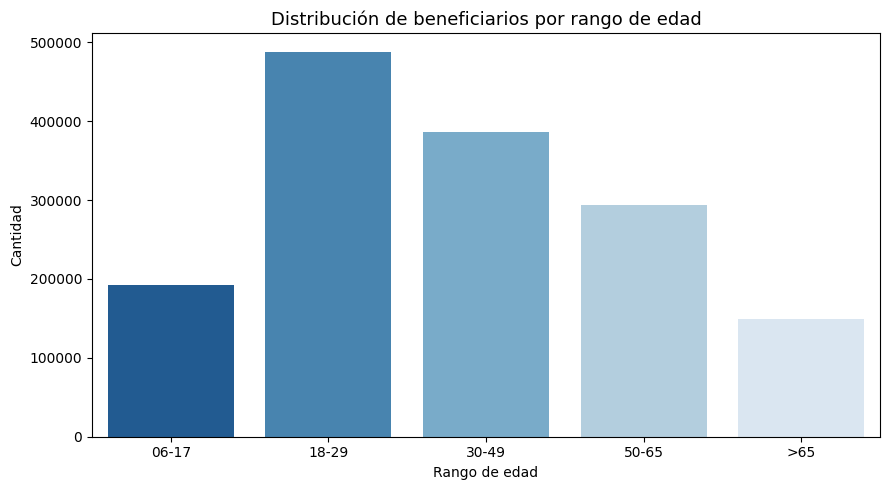

In [58]:
df_edad = dfBeneficiarios.groupBy("RangoEdad").count().orderBy("RangoEdad").toPandas()

plt.figure(figsize=(9,5))
sns.barplot(data=df_edad, x="RangoEdad", y="count", hue = 'RangoEdad', palette="Blues_r")
plt.title("Distribución de beneficiarios por rango de edad", fontsize=13)
plt.xlabel("Rango de edad")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

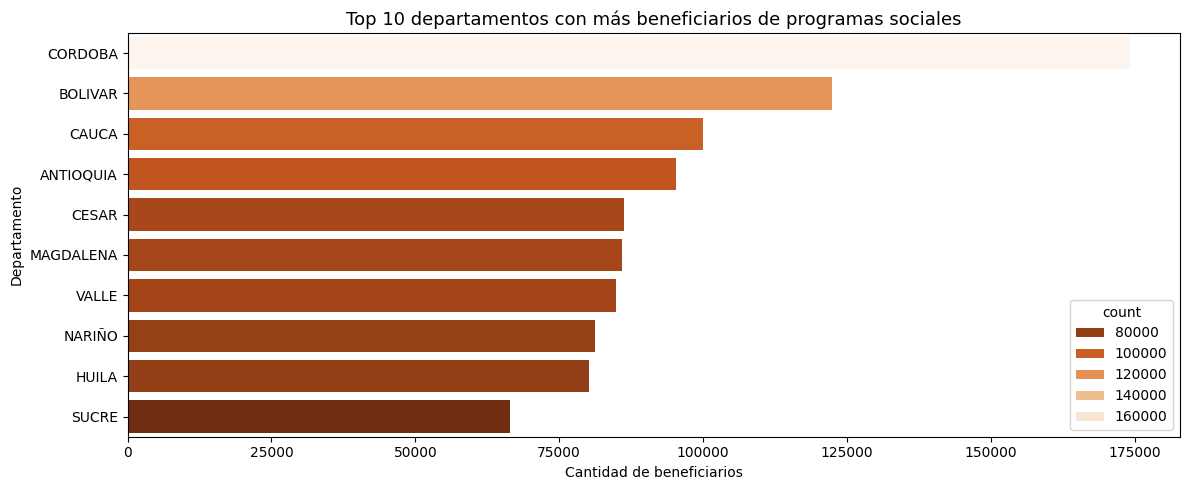

In [59]:
df_dpto = dfBeneficiarios.groupBy("NombreDepartamentoAtencion") \
    .count().orderBy("count", ascending=False).limit(10).toPandas()

plt.figure(figsize=(12,5))
sns.barplot(data=df_dpto, x="count", y="NombreDepartamentoAtencion", hue = 'count', palette="Oranges_r")
plt.title("Top 10 departamentos con más beneficiarios de programas sociales", fontsize=13)
plt.xlabel("Cantidad de beneficiarios")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()

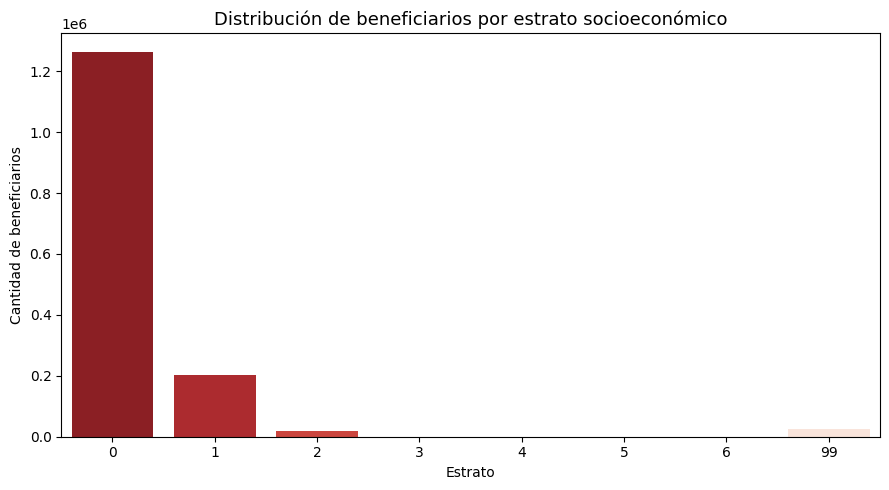

In [60]:
df_estrato = dfBeneficiarios.groupBy("Estrato").count().orderBy("Estrato").toPandas()

plt.figure(figsize=(9,5))
sns.barplot(data=df_estrato, x="Estrato", y="count", hue = 'Estrato', palette="Reds_r")
plt.title("Distribución de beneficiarios por estrato socioeconómico", fontsize=13)
plt.xlabel("Estrato")
plt.ylabel("Cantidad de beneficiarios")
plt.tight_layout()
plt.show()

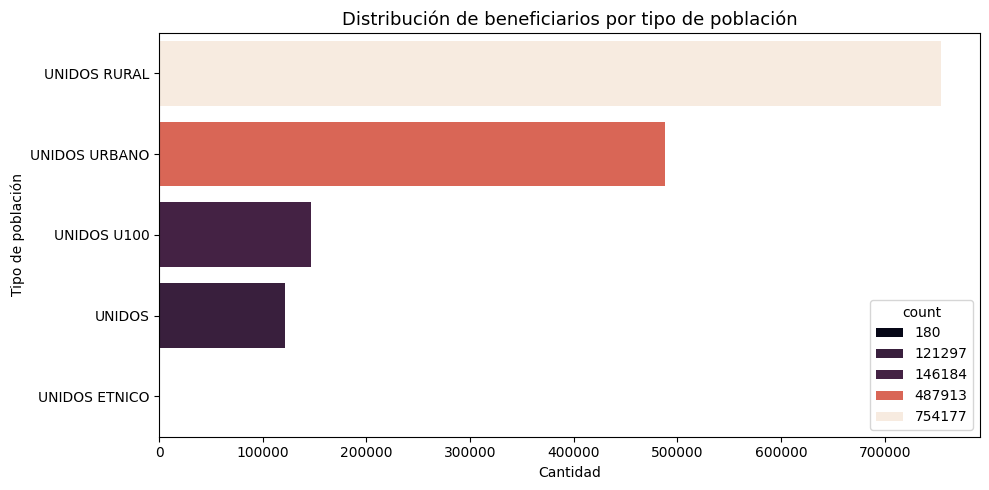

In [61]:
df_tipo = dfBeneficiarios.groupBy("TipoPoblacion").count() \
    .orderBy("count", ascending=False).toPandas()

plt.figure(figsize=(10,5))
sns.barplot(data=df_tipo, x="count", y="TipoPoblacion", hue = 'count', palette="rocket")
plt.title("Distribución de beneficiarios por tipo de población", fontsize=13)
plt.xlabel("Cantidad")
plt.ylabel("Tipo de población")
plt.tight_layout()
plt.show()

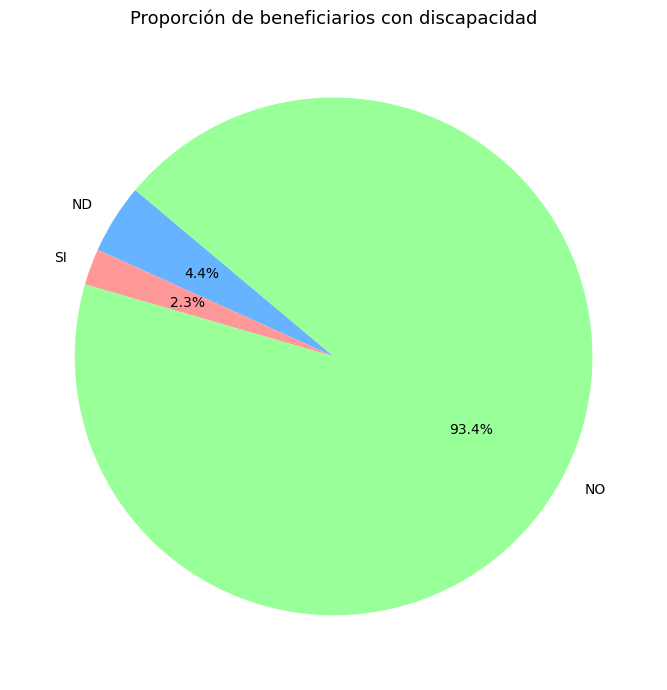

In [62]:
df_disc = dfBeneficiarios.groupBy("Discapacidad").count().toPandas()

plt.figure(figsize=(7,7))
plt.pie(df_disc["count"], labels=df_disc["Discapacidad"],
        autopct="%1.1f%%", startangle=140, colors=["#66b3ff","#ff9999","#99ff99"])
plt.title("Proporción de beneficiarios con discapacidad", fontsize=13)
plt.tight_layout()
plt.show()

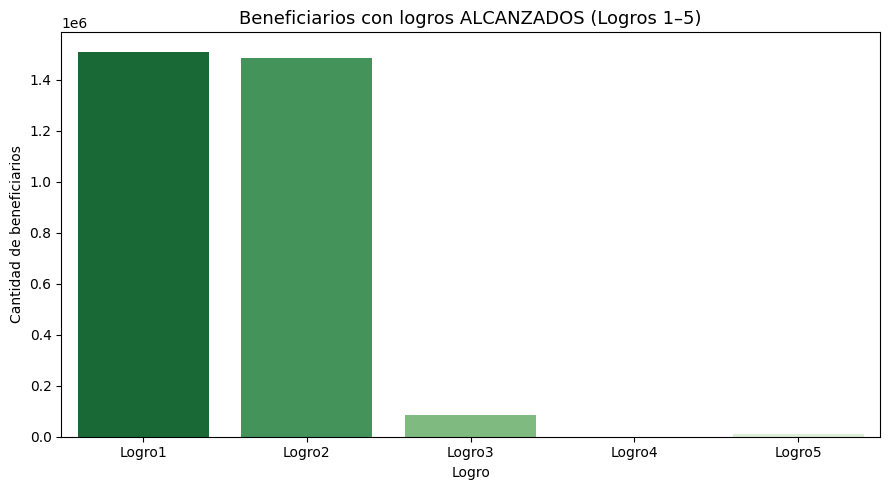

In [63]:
from pyspark.sql.functions import when, col

logros = ["Logro1","Logro2","Logro3","Logro4","Logro5"]
resumen = []
0.
for logro in logros:
    total = dfBeneficiarios.filter(col(logro) == "ALCANZADO").count()
    resumen.append({"Logro": logro, "ALCANZADO": total})

import pandas as pd
df_logros = pd.DataFrame(resumen)

plt.figure(figsize=(9,5))
sns.barplot(data=df_logros, x="Logro", y="ALCANZADO", hue = 'Logro',palette="Greens_r")
plt.title("Beneficiarios con logros ALCANZADOS (Logros 1–5)", fontsize=13)
plt.xlabel("Logro")
plt.ylabel("Cantidad de beneficiarios")
plt.tight_layout()
plt.show()

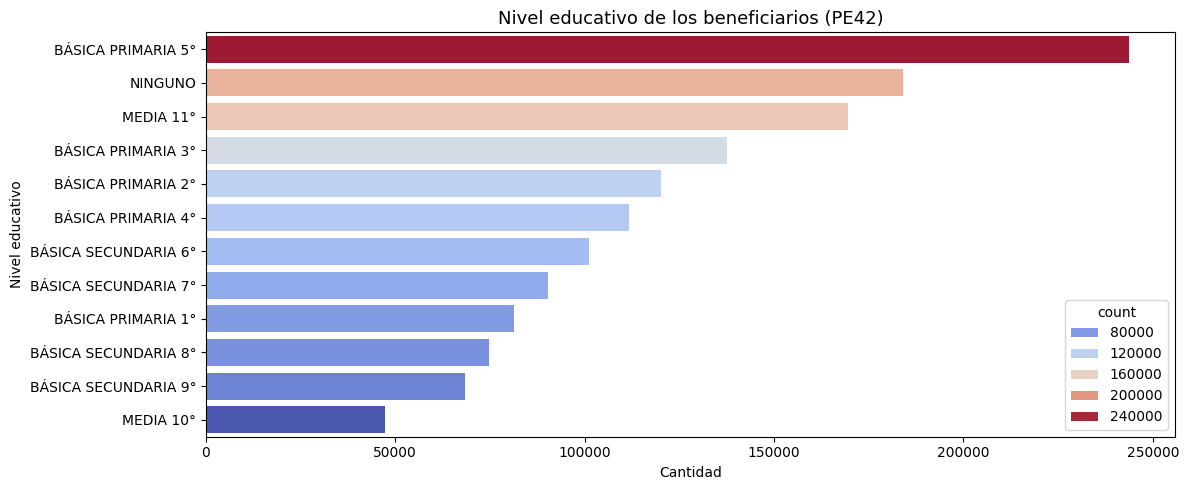

In [64]:
df_edu = dfBeneficiarios.groupBy("PE42").count() \
    .orderBy("count", ascending=False).limit(12).toPandas()

plt.figure(figsize=(12,5))
sns.barplot(data=df_edu, x="count", y="PE42",hue = 'count', palette="coolwarm")
plt.title("Nivel educativo de los beneficiarios (PE42)", fontsize=13)
plt.xlabel("Cantidad")
plt.ylabel("Nivel educativo")
plt.tight_layout()
plt.show()

In [65]:
# ── Limpieza SISBEN, binarización de logros (Entrega 1) ──
dfBeneficiarios_clean = dfBeneficiarios \
    .withColumn("PuntajeSISBEN",
                when(col("PuntajeSISBEN") == "ND", None)
                .otherwise(col("PuntajeSISBEN").cast("integer"))) \
    .withColumn("CondicionSexual",
                when(col("CondicionSexual").isNull(), "Sin Información")
                .otherwise(col("CondicionSexual"))) \
    .withColumn("Logro1_BIN",
                when(col("Logro1") == "ALCANZADO", 1).otherwise(0)) \
    .withColumn("Logro2_BIN",
                when(col("Logro2") == "ALCANZADO", 1).otherwise(0)) \
    .withColumn("Logro3_BIN",
                when(col("Logro3") == "ALCANZADO", 1).otherwise(0))

print("Nulos en PuntajeSISBEN después de limpieza:",
      dfBeneficiarios_clean.filter(col("PuntajeSISBEN").isNull()).count())

[Stage 265:=====================================>                  (8 + 4) / 12]

Nulos en PuntajeSISBEN después de limpieza: 0


# Filtros, limpieza y transformación inicial


### Municipios focalizados
El análisis territorial de la Entrega 1 se realizó a nivel departamental (Bogotá, Antioquia, Santander vs Chocó, Nariño, Vaupés). Para la Entrega 2, el enfoque se ajusta a **nivel municipal** tal como lo requiere el proyecto, seleccionando los tres municipios más representativos y con mayor disponibilidad de datos:

| Grupo | Municipio | Departamento | Justificación |
|---|---|---|---|
| A — Alto desarrollo | **Bogotá D.C.** | Cundinamarca / Distrito | Capital nacional, mayor volumen de datos ICFES e internet |
| B — Alta vulnerabilidad | **Quibdó** | Chocó | Capital del departamento con menor IDH del país |
| B — Alta vulnerabilidad | **Pasto** | Nariño | Municipio fronterizo con alta ruralidad y brechas educativas |

In [66]:
# ── Definición de grupos municipales ──
grupo_a_mcpio = ["BOGOTA"]
grupo_b_mcpio = ["QUIBDO", "PASTO"]

print("Municipios Grupo A (Alto desarrollo):", grupo_a_mcpio)
print("Municipios Grupo B (Alta vulnerabilidad):", grupo_b_mcpio)

Municipios Grupo A (Alto desarrollo): ['BOGOTA']
Municipios Grupo B (Alta vulnerabilidad): ['QUIBDO', 'PASTO']


### Filtrar ICFES por los tres municipios de análisis 

In [67]:
# Se usa .like() porque Bogotá puede aparecer como 'BOGOTA D.C.', 'BOGOTA D.C', etc.
# Primero normalizamos a etiquetas estándar para consistencia en todos los gráficos
dfICFES_mcpio = dfICFES_clean \
    .withColumn("MUNICIPIO_STD",
        when(col("COLE_MCPIO_UBICACION").like("%BOGOT%"), "BOGOTA")
        .when(col("COLE_MCPIO_UBICACION").like("%QUIBD%"), "QUIBDO")
        .when(col("COLE_MCPIO_UBICACION") == "PASTO", "PASTO")
        .otherwise(None)) \
    .filter(col("MUNICIPIO_STD").isNotNull()) \
    .withColumn("COLE_MCPIO_UBICACION", col("MUNICIPIO_STD")) \
    .drop("MUNICIPIO_STD") \
    .withColumn("GRUPO",
        when(col("COLE_MCPIO_UBICACION") == "BOGOTA", "Grupo A - Alto desarrollo")
        .otherwise("Grupo B - Alta vulnerabilidad"))

print("Registros por municipio:")
dfICFES_mcpio.groupBy("COLE_MCPIO_UBICACION", "GRUPO").count().show()

Registros por municipio:


[Stage 268:===================================================>   (26 + 2) / 28]

+--------------------+--------------------+------+
|COLE_MCPIO_UBICACION|               GRUPO| count|
+--------------------+--------------------+------+
|              BOGOTA|Grupo A - Alto de...|709169|
|               PASTO|Grupo B - Alta vu...| 41256|
|              QUIBDO|Grupo B - Alta vu...| 13400|
+--------------------+--------------------+------+



In [68]:
# ── Variable objetivo binaria para clasificación GBT ──
# Umbral = 300 puntos (≈ percentil 50 de la distribución nacional)
dfICFES_mcpio = dfICFES_mcpio \
    .withColumn("PUNT_GLOBAL_NUM", col("PUNT_GLOBAL").cast("double")) \
    .withColumn("label",
        when(col("PUNT_GLOBAL_NUM") >= 300, 1.0)
        .otherwise(0.0))

print("Distribución de clases (0=puntaje bajo, 1=puntaje alto):")
dfICFES_mcpio.groupBy("COLE_MCPIO_UBICACION", "label").count() \
    .orderBy("COLE_MCPIO_UBICACION", "label").show()

Distribución de clases (0=puntaje bajo, 1=puntaje alto):


[Stage 271:=====================================================> (27 + 1) / 28]

+--------------------+-----+------+
|COLE_MCPIO_UBICACION|label| count|
+--------------------+-----+------+
|              BOGOTA|  0.0|504631|
|              BOGOTA|  1.0|204538|
|               PASTO|  0.0| 28953|
|               PASTO|  1.0| 12303|
|              QUIBDO|  0.0| 12663|
|              QUIBDO|  1.0|   737|
+--------------------+-----+------+



### Filtrar internet y educación para los tres municipios 


In [69]:
dfInternet_foco = dfInternet_mcpio \
    .withColumn("MUNICIPIO_NORM",
        regexp_replace(upper(trim(col("MUNICIPIO"))), "Ó", "O")) \
    .filter(col("MUNICIPIO_NORM").isin(["BOGOTA", "QUIBDO", "PASTO"]))

dfEdu_foco = dfEdu_clean.filter(col("AÑO") >= 2017) \
    .withColumn("MCPIO_NORM",
        when(upper(trim(col("MUNICIPIO"))).like("%BOGOT%"), "BOGOTA")
        .when(upper(trim(col("MUNICIPIO"))).like("%QUIBD%"), "QUIBDO")
        .when(upper(trim(col("MUNICIPIO"))).like("%PASTO%"), "PASTO")
        .otherwise(None)) \
    .filter(col("MCPIO_NORM").isNotNull())

print("Registros internet en municipios de análisis:", dfInternet_foco.count())
print("Registros educativos en municipios de análisis:", dfEdu_foco.count())

Registros internet en municipios de análisis: 14
Registros educativos en municipios de análisis: 24


In [70]:
df_icfes_agg = dfICFES_mcpio \
    .groupBy("COLE_MCPIO_UBICACION", "AÑO", "GRUPO") \
    .agg(
        F.avg("PUNT_GLOBAL_NUM").alias("PUNTAJE_GLOBAL_PROM"),
        F.avg("PUNT_MATEMATICAS").alias("PUNTAJE_MATE_PROM"),
        F.avg("PUNT_LECTURA_CRITICA").alias("PUNTAJE_LECT_PROM"),
        F.avg("TIENE_INTERNET_BIN").alias("PROP_INTERNET_HOGAR"),
        F.avg("ESTRATO_NUM").alias("ESTRATO_PROM"),
        F.count("*").alias("N_ESTUDIANTES")
    ).withColumnRenamed("COLE_MCPIO_UBICACION", "MUNICIPIO")

df_inet_agg = dfInternet_foco \
    .drop("MUNICIPIO") \
    .withColumnRenamed("MUNICIPIO_NORM", "MUNICIPIO") \
    .groupBy("MUNICIPIO", "AÑO") \
    .agg(Fsum("TOTAL_ACCESOS").alias("TOTAL_ACCESOS"))

df_master = df_icfes_agg.join(df_inet_agg, on=["MUNICIPIO", "AÑO"], how="left")

print("Tabla maestra municipal:")
df_master.orderBy("MUNICIPIO", "AÑO").show(20)

Tabla maestra municipal:


[Stage 283:=====================================================> (27 + 1) / 28]

+---------+----+--------------------+-------------------+------------------+------------------+-------------------+------------------+-------------+-------------+
|MUNICIPIO| AÑO|               GRUPO|PUNTAJE_GLOBAL_PROM| PUNTAJE_MATE_PROM| PUNTAJE_LECT_PROM|PROP_INTERNET_HOGAR|      ESTRATO_PROM|N_ESTUDIANTES|TOTAL_ACCESOS|
+---------+----+--------------------+-------------------+------------------+------------------+-------------------+------------------+-------------+-------------+
|   BOGOTA|2014|Grupo A - Alto de...|  268.4251208255323| 53.28914311838725| 53.91876387860844| 0.8045801526717558|  2.41302652534461|        91868|         NULL|
|   BOGOTA|2015|Grupo A - Alto de...|  270.1382348379091| 54.55391137997001| 53.14849283904658| 0.8290658515102844|2.4709027540773376|        96705|         NULL|
|   BOGOTA|2016|Grupo A - Alto de...| 279.48603962109087|55.500302781262164| 55.89763830615511| 0.8363646217212226|2.4545109849633833|        92476|         NULL|
|   BOGOTA|2017|Grupo 

# Respuesta a las preguntas de negocio

Preguntas adaptadas al nivel municipal (Bogotá, Quibdó, Pasto).

### P1 ¿Existe diferencia significativa en el puntaje ICFES entre municipios de alto desarrollo y alta vulnerabilidad, y en qué medida se relaciona con el acceso a internet fijo?

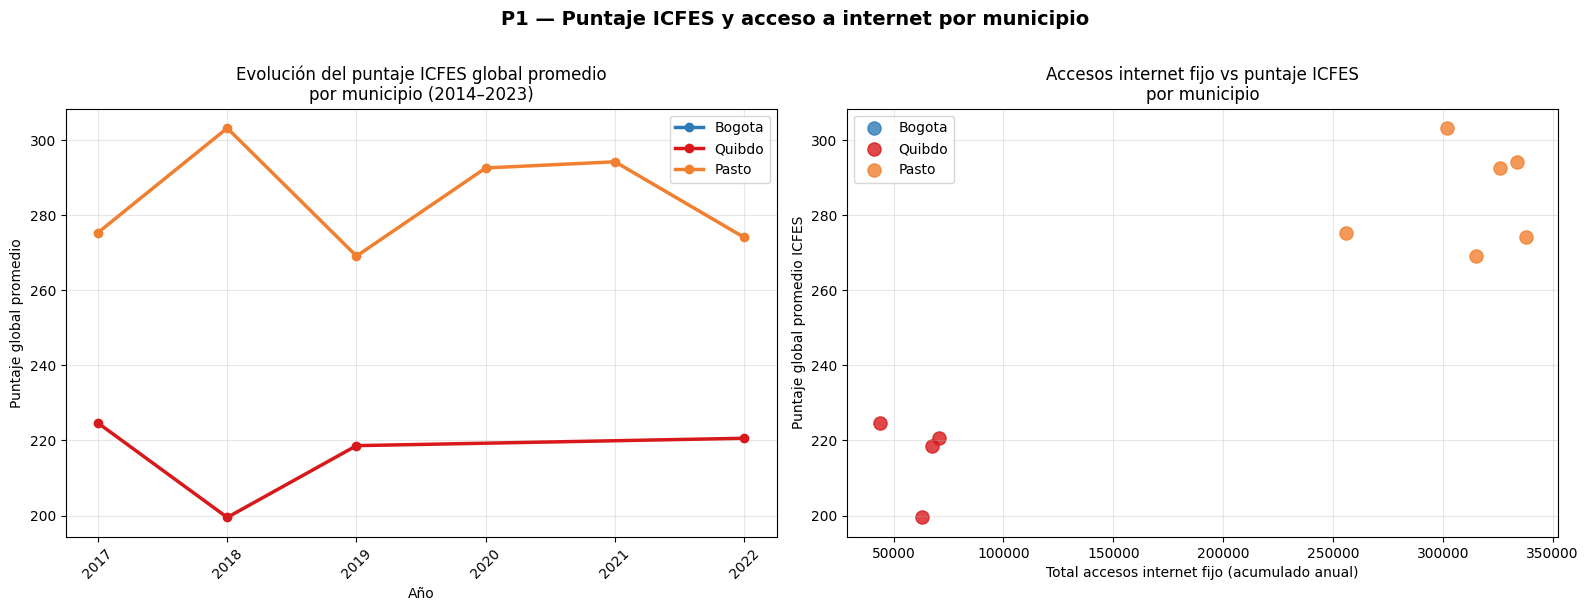

,PUNTAJE_GLOBAL_PROM,TOTAL_ACCESOS
MUNICIPIO,,
PASTO,284.74,311829.00
QUIBDO,215.84,61146.75


In [71]:
df_p1 = df_master.select(
    "MUNICIPIO", "AÑO", "GRUPO", "PUNTAJE_GLOBAL_PROM", "TOTAL_ACCESOS"
).dropna().toPandas()

df_p1["AÑO"] = df_p1["AÑO"].astype(int)

colores = {"BOGOTA": "#2c7bb6", "QUIBDO": "#d7191c", "PASTO": "#f08030"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for mcpio in ["BOGOTA", "QUIBDO", "PASTO"]:
    sub = df_p1[df_p1["MUNICIPIO"] == mcpio].sort_values("AÑO")
    axes[0].plot(sub["AÑO"], sub["PUNTAJE_GLOBAL_PROM"],
                 marker="o", label=mcpio.title(), color=colores[mcpio], linewidth=2.5)
axes[0].set_title("Evolución del puntaje ICFES global promedio\npor municipio (2014–2023)", fontsize=12)
axes[0].set_xlabel("Año")
axes[0].set_ylabel("Puntaje global promedio")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(alpha=0.3)

for mcpio in ["BOGOTA", "QUIBDO", "PASTO"]:
    sub = df_p1[df_p1["MUNICIPIO"] == mcpio]
    axes[1].scatter(sub["TOTAL_ACCESOS"], sub["PUNTAJE_GLOBAL_PROM"],
                    label=mcpio.title(), color=colores[mcpio], s=90, alpha=0.8)
axes[1].set_title("Accesos internet fijo vs puntaje ICFES\npor municipio", fontsize=12)
axes[1].set_xlabel("Total accesos internet fijo (acumulado anual)")
axes[1].set_ylabel("Puntaje global promedio ICFES")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("P1 — Puntaje ICFES y acceso a internet por municipio",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

df_p1.groupby("MUNICIPIO")[["PUNTAJE_GLOBAL_PROM", "TOTAL_ACCESOS"]].mean().round(2)

### P2 — ¿Los municipios del Grupo B presentan menor cobertura neta en secundaria y cómo se relaciona con sus resultados en ICFES?

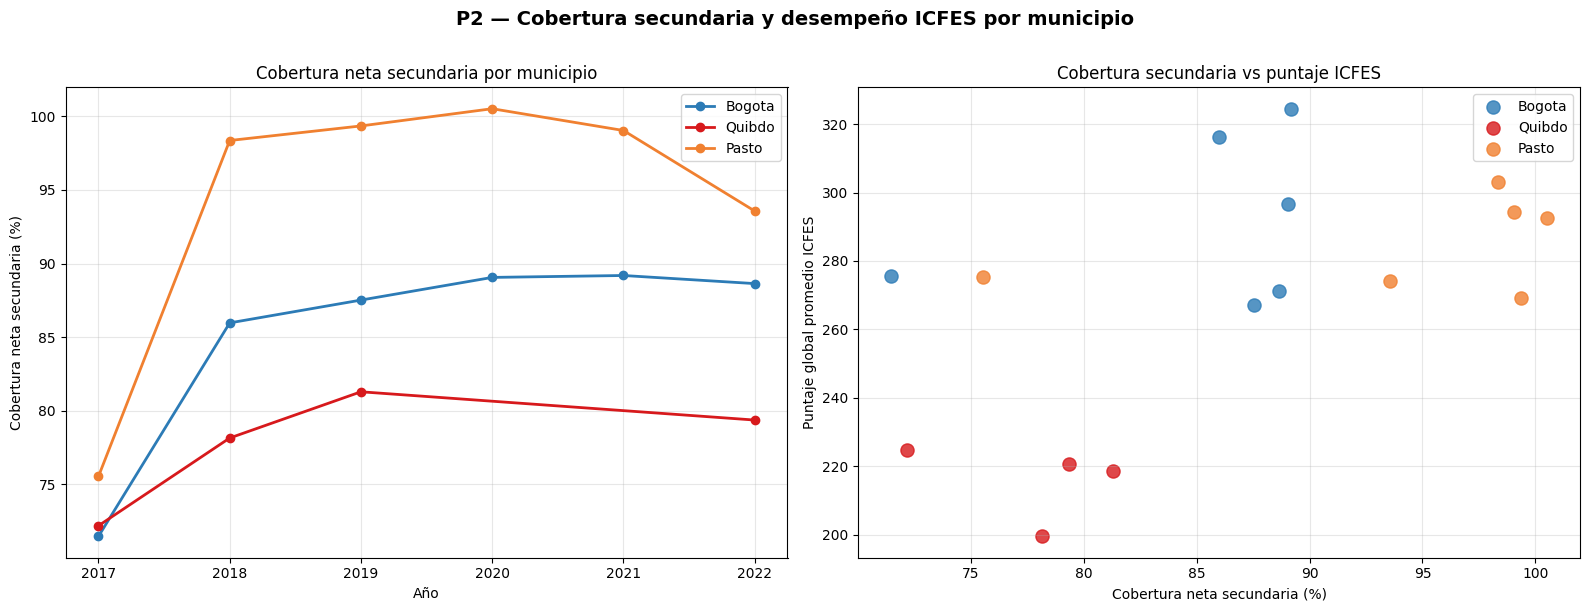

,COB_SECUNDARIA,PUNTAJE_GLOBAL_PROM
MCPIO_NORM,,
BOGOTA,85.31,291.84
PASTO,94.40,284.74
QUIBDO,77.75,215.84


In [72]:
df_cob_mun = dfEdu_foco \
    .groupBy("MCPIO_NORM", "AÑO") \
    .agg(F.avg("COBERTURA_NETA_SECUNDARIA").alias("COB_SECUNDARIA")) \
    .orderBy("MCPIO_NORM", "AÑO").toPandas()

df_icfes_p2 = df_master.select("MUNICIPIO", "AÑO", "PUNTAJE_GLOBAL_PROM").dropna().toPandas()
df_icfes_p2["AÑO"] = df_icfes_p2["AÑO"].astype(int)
df_cob_mun["AÑO"]  = df_cob_mun["AÑO"].astype(int)

df_p2 = df_cob_mun.merge(df_icfes_p2, left_on=["MCPIO_NORM", "AÑO"],
                          right_on=["MUNICIPIO", "AÑO"], how="inner")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for mcpio in ["BOGOTA", "QUIBDO", "PASTO"]:
    sub = df_p2[df_p2["MCPIO_NORM"] == mcpio].sort_values("AÑO")
    axes[0].plot(sub["AÑO"], sub["COB_SECUNDARIA"],
                 marker="o", label=mcpio.title(), color=colores[mcpio], linewidth=2)
axes[0].set_title("Cobertura neta secundaria por municipio", fontsize=12)
axes[0].set_xlabel("Año")
axes[0].set_ylabel("Cobertura neta secundaria (%)")
axes[0].legend()
axes[0].grid(alpha=0.3)

for mcpio in ["BOGOTA", "QUIBDO", "PASTO"]:
    sub = df_p2[df_p2["MCPIO_NORM"] == mcpio]
    axes[1].scatter(sub["COB_SECUNDARIA"], sub["PUNTAJE_GLOBAL_PROM"],
                    label=mcpio.title(), color=colores[mcpio], s=90, alpha=0.8)
axes[1].set_title("Cobertura secundaria vs puntaje ICFES", fontsize=12)
axes[1].set_xlabel("Cobertura neta secundaria (%)")
axes[1].set_ylabel("Puntaje global promedio ICFES")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("P2 — Cobertura secundaria y desempeño ICFES por municipio",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

df_p2.groupby("MCPIO_NORM")[["COB_SECUNDARIA", "PUNTAJE_GLOBAL_PROM"]].mean().round(2)

### P3 — ¿Cómo varía la brecha de puntaje ICFES entre colegios oficiales y no oficiales dentro de cada municipio?

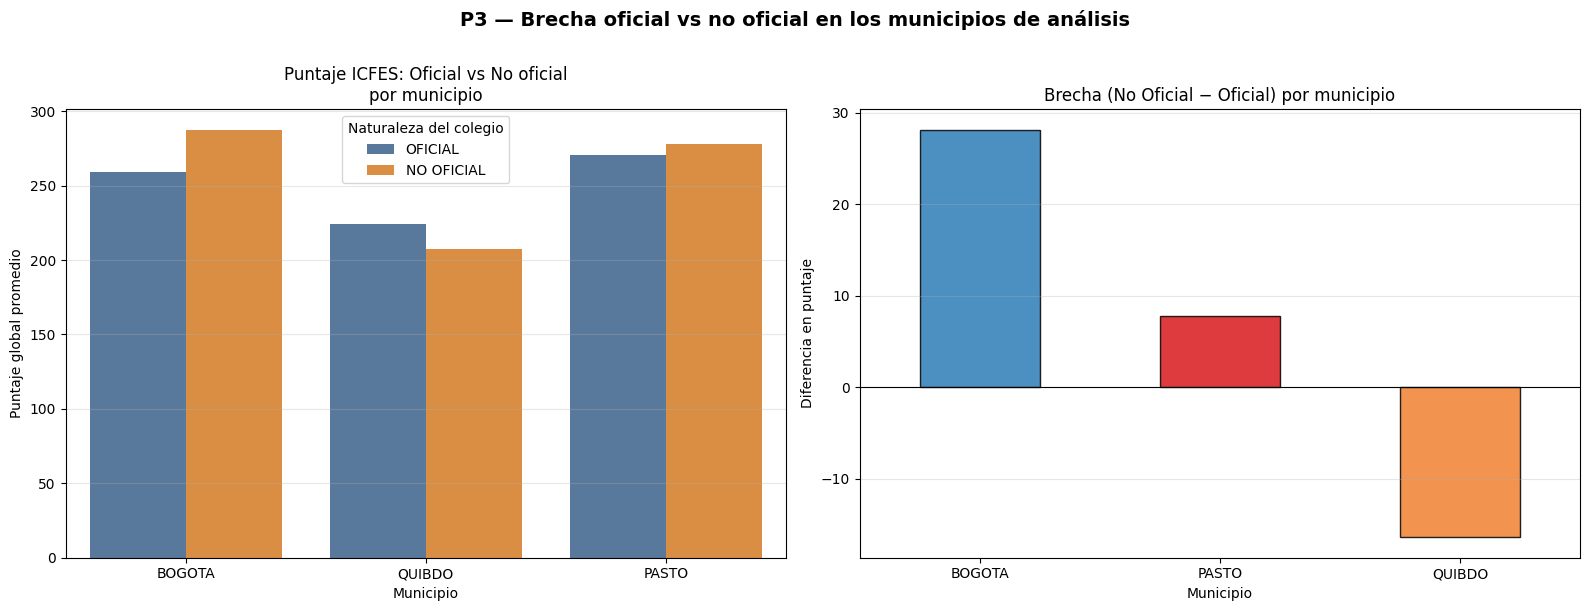

Brecha por municipio (No oficial − Oficial):
COLE_NATURALEZA       OFICIAL  NO OFICIAL  BRECHA
COLE_MCPIO_UBICACION                             
BOGOTA                 258.85      287.00   28.15
PASTO                  270.37      278.20    7.83
QUIBDO                 224.08      207.68  -16.40


In [73]:
df_p3 = dfICFES_mcpio \
    .filter(col("COLE_NATURALEZA").isin(["OFICIAL", "NO OFICIAL"])) \
    .filter(col("PUNT_GLOBAL_NUM").isNotNull()) \
    .groupBy("COLE_MCPIO_UBICACION", "COLE_NATURALEZA", "GRUPO") \
    .agg(
        F.avg("PUNT_GLOBAL_NUM").alias("PUNTAJE_PROM"),
        F.count("*").alias("N_ESTUDIANTES")
    ).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=df_p3, x="COLE_MCPIO_UBICACION", y="PUNTAJE_PROM",
            hue="COLE_NATURALEZA", palette=["#4e79a7", "#f28e2b"], ax=axes[0])
axes[0].set_title("Puntaje ICFES: Oficial vs No oficial\npor municipio", fontsize=12)
axes[0].set_xlabel("Municipio")
axes[0].set_ylabel("Puntaje global promedio")
axes[0].legend(title="Naturaleza del colegio")
axes[0].grid(alpha=0.3, axis="y")

df_p3_pivot = df_p3.pivot_table(index="COLE_MCPIO_UBICACION",
                                  columns="COLE_NATURALEZA",
                                  values="PUNTAJE_PROM")
df_p3_pivot["BRECHA"] = df_p3_pivot["NO OFICIAL"] - df_p3_pivot["OFICIAL"]
df_p3_pivot["BRECHA"].plot(kind="bar", color=["#2c7bb6", "#d7191c", "#f08030"],
                            ax=axes[1], rot=0, alpha=0.85, edgecolor="black")
axes[1].set_title("Brecha (No Oficial − Oficial) por municipio", fontsize=12)
axes[1].set_xlabel("Municipio")
axes[1].set_ylabel("Diferencia en puntaje")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].grid(alpha=0.3, axis="y")

plt.suptitle("P3 — Brecha oficial vs no oficial en los municipios de análisis",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Brecha por municipio (No oficial − Oficial):")
print(df_p3_pivot[["OFICIAL", "NO OFICIAL", "BRECHA"]].round(2))

### P4 — ¿Difiere la relación entre estrato socioeconómico y desempeño ICFES entre los municipios del Grupo A y del Grupo B?

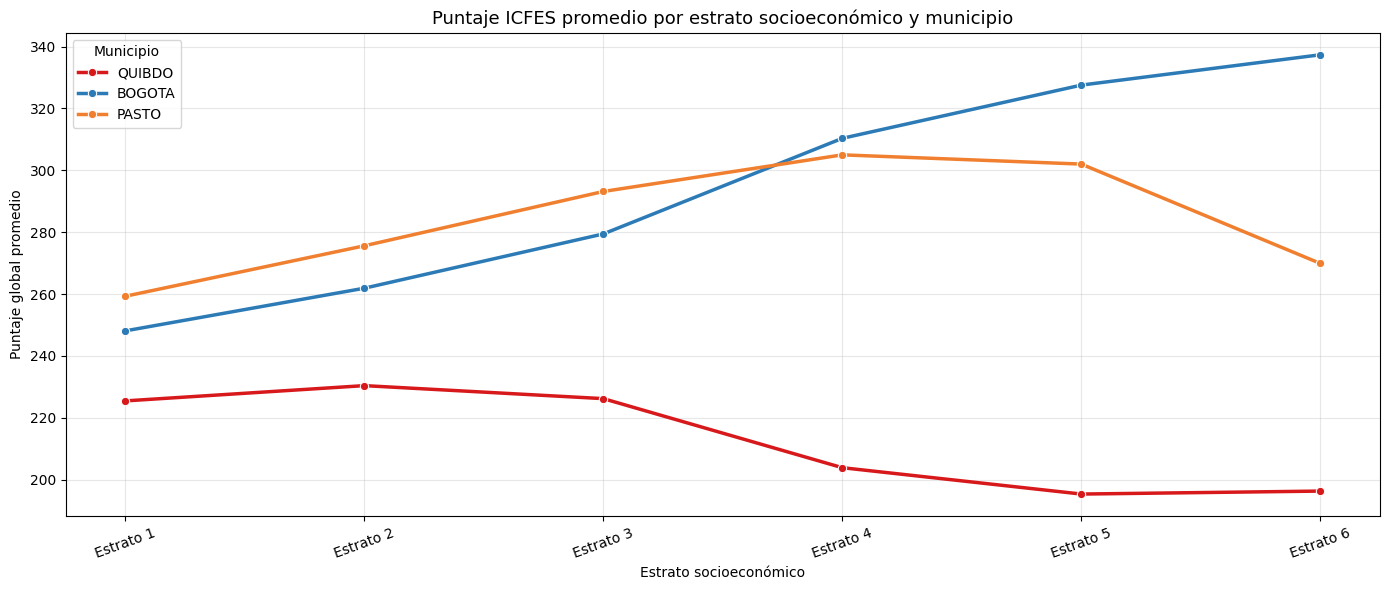

,COLE_MCPIO_UBICACION,FAMI_ESTRATOVIVIENDA,PUNTAJE_PROM,N
0,QUIBDO,Estrato 1,225.44,8659
1,BOGOTA,Estrato 1,248.09,71494
2,PASTO,Estrato 1,259.28,16074
3,BOGOTA,Estrato 2,261.88,301621
4,QUIBDO,Estrato 2,230.38,1776
5,PASTO,Estrato 2,275.59,13887
6,QUIBDO,Estrato 3,226.17,956
7,PASTO,Estrato 3,293.16,6532
8,BOGOTA,Estrato 3,279.43,233744
9,QUIBDO,Estrato 4,203.84,349


In [74]:
estratos_validos = ["Estrato 1", "Estrato 2", "Estrato 3",
                    "Estrato 4", "Estrato 5", "Estrato 6"]

df_p4 = dfICFES_mcpio \
    .filter(col("FAMI_ESTRATOVIVIENDA").isin(estratos_validos)) \
    .filter(col("PUNT_GLOBAL_NUM").isNotNull()) \
    .groupBy("COLE_MCPIO_UBICACION", "FAMI_ESTRATOVIVIENDA", "GRUPO") \
    .agg(F.avg("PUNT_GLOBAL_NUM").alias("PUNTAJE_PROM"),
         F.count("*").alias("N")) \
    .orderBy("FAMI_ESTRATOVIVIENDA").toPandas()

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_p4, x="FAMI_ESTRATOVIVIENDA", y="PUNTAJE_PROM",
             hue="COLE_MCPIO_UBICACION",
             palette={"BOGOTA": "#2c7bb6", "QUIBDO": "#d7191c", "PASTO": "#f08030"},
             marker="o", linewidth=2.5)
plt.title("Puntaje ICFES promedio por estrato socioeconómico y municipio", fontsize=13)
plt.xlabel("Estrato socioeconómico")
plt.ylabel("Puntaje global promedio")
plt.xticks(rotation=20)
plt.legend(title="Municipio")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

df_p4[["COLE_MCPIO_UBICACION", "FAMI_ESTRATOVIVIENDA", "PUNTAJE_PROM", "N"]].round(2)

### P5 — ¿Los municipios del Grupo B concentran mayor proporción de beneficiarios de programas sociales y coinciden con los de menor puntaje ICFES?

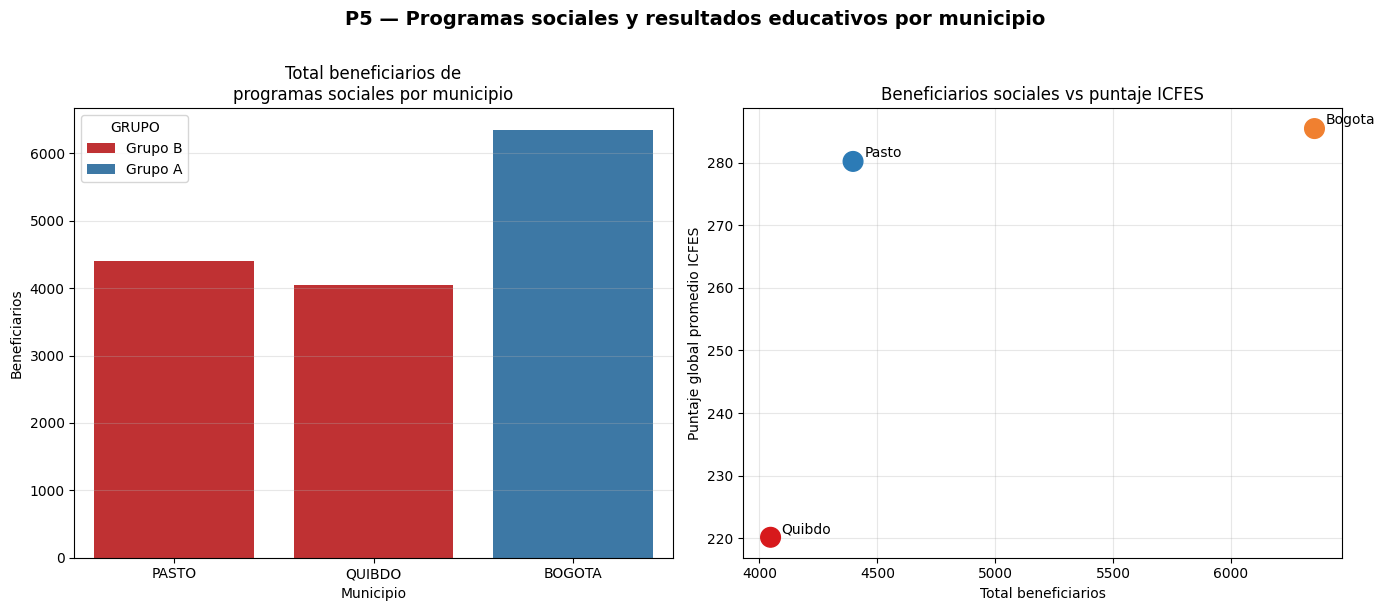

,MCPIO_NORM,GRUPO,TOTAL_BENEFICIARIOS,PUNTAJE_PROM
0,PASTO,Grupo B,4397,280.21
1,QUIBDO,Grupo B,4047,220.15
2,BOGOTA,Grupo A,6355,285.46


In [75]:
df_ben_mcpio = dfBeneficiarios_clean \
    .withColumn("MCPIO_NORM",
        when(upper(trim(col("NombreMunicipioAtencion"))).like("%BOGOT%"), "BOGOTA")
        .when(upper(trim(col("NombreMunicipioAtencion"))).like("%QUIBD%"), "QUIBDO")
        .when(upper(trim(col("NombreMunicipioAtencion"))).like("%PASTO%"), "PASTO")
        .otherwise(None)) \
    .filter(col("MCPIO_NORM").isNotNull()) \
    .groupBy("MCPIO_NORM") \
    .count() \
    .withColumnRenamed("count", "TOTAL_BENEFICIARIOS").toPandas()

df_icfes_p5 = df_master.groupBy("MUNICIPIO") \
    .agg(F.avg("PUNTAJE_GLOBAL_PROM").alias("PUNTAJE_PROM")).toPandas()

df_p5 = df_ben_mcpio.merge(df_icfes_p5, left_on="MCPIO_NORM", right_on="MUNICIPIO")
df_p5["GRUPO"] = df_p5["MCPIO_NORM"].map(
    {"BOGOTA": "Grupo A", "QUIBDO": "Grupo B", "PASTO": "Grupo B"})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=df_p5, x="MCPIO_NORM", y="TOTAL_BENEFICIARIOS",
            hue="GRUPO", palette={"Grupo A": "#2c7bb6", "Grupo B": "#d7191c"},
            ax=axes[0], dodge=False)
axes[0].set_title("Total beneficiarios de\nprogramas sociales por municipio", fontsize=12)
axes[0].set_xlabel("Municipio")
axes[0].set_ylabel("Beneficiarios")
axes[0].grid(alpha=0.3, axis="y")

axes[1].scatter(df_p5["TOTAL_BENEFICIARIOS"], df_p5["PUNTAJE_PROM"],
                c=["#2c7bb6", "#d7191c", "#f08030"], s=200, zorder=5)
for _, row in df_p5.iterrows():
    axes[1].annotate(row["MCPIO_NORM"].title(),
                     (row["TOTAL_BENEFICIARIOS"], row["PUNTAJE_PROM"]),
                     xytext=(8, 3), textcoords="offset points", fontsize=10)
axes[1].set_title("Beneficiarios sociales vs puntaje ICFES", fontsize=12)
axes[1].set_xlabel("Total beneficiarios")
axes[1].set_ylabel("Puntaje global promedio ICFES")
axes[1].grid(alpha=0.3)

plt.suptitle("P5 — Programas sociales y resultados educativos por municipio",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

df_p5[["MCPIO_NORM", "GRUPO", "TOTAL_BENEFICIARIOS", "PUNTAJE_PROM"]].round(2)

### P6 — ¿Qué tecnologías de internet predominan en los municipios vulnerables y cómo ha evolucionado su cobertura?

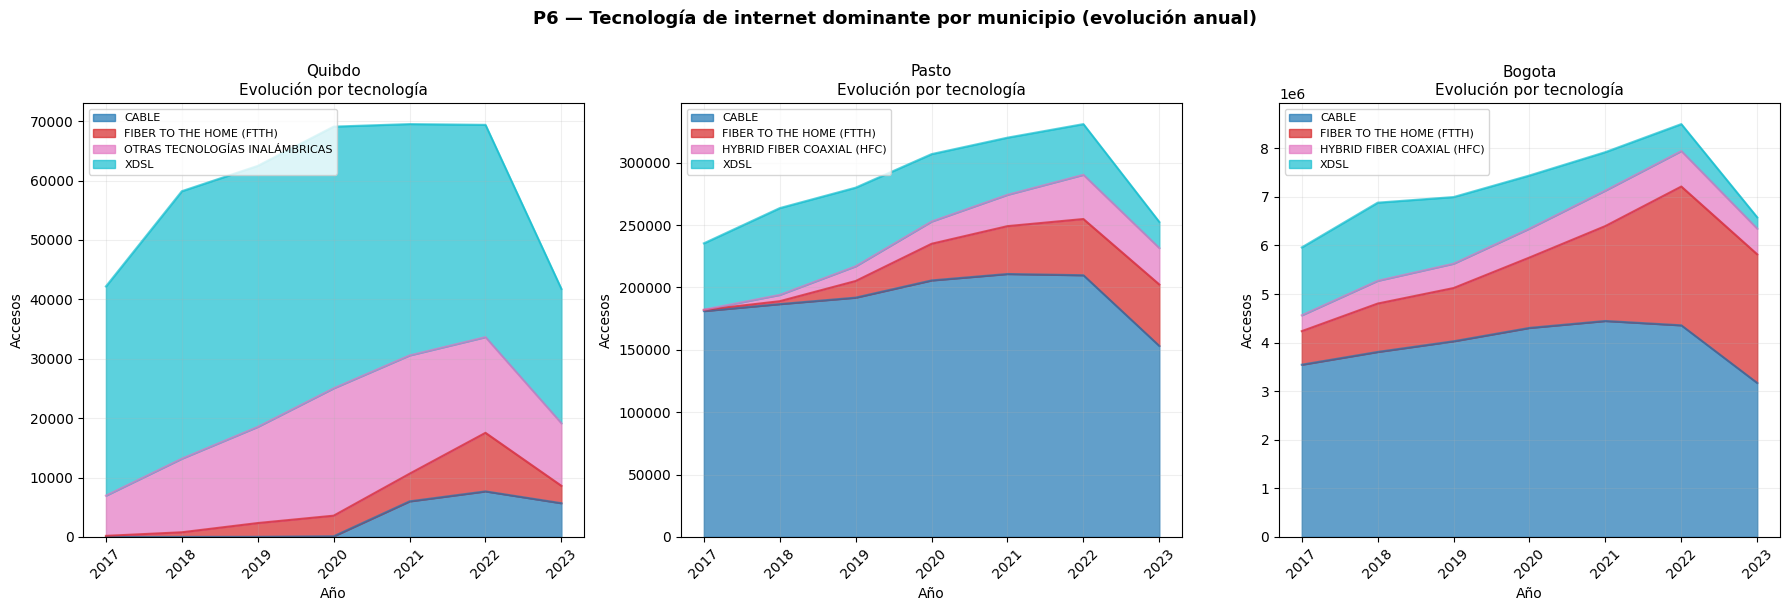

In [76]:
df_p6 = dfInternet_clean \
    .withColumn("MCPIO_NORM",
        when(upper(trim(col("MUNICIPIO"))).like("%BOGOT%"), "BOGOTA")
        .when(upper(trim(col("MUNICIPIO"))).like("%QUIBD%"), "QUIBDO")
        .when(upper(trim(col("MUNICIPIO"))).like("%PASTO%"), "PASTO")
        .otherwise(None)) \
    .filter(col("MCPIO_NORM").isNotNull()) \
    .groupBy("MCPIO_NORM", "AÑO", "TECNOLOGIA") \
    .agg(Fsum("ACCESOS_NUM").alias("ACCESOS")) \
    .orderBy("MCPIO_NORM", "AÑO").toPandas()

df_p6["AÑO"] = df_p6["AÑO"].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

for i, mcpio in enumerate(["QUIBDO", "PASTO", "BOGOTA"]):
    sub = df_p6[df_p6["MCPIO_NORM"] == mcpio]
    top_tec = sub.groupby("TECNOLOGIA")["ACCESOS"].sum().nlargest(4).index.tolist()
    sub_top = sub[sub["TECNOLOGIA"].isin(top_tec)]
    pivot = sub_top.pivot_table(index="AÑO", columns="TECNOLOGIA", values="ACCESOS", aggfunc="sum").fillna(0)
    pivot.plot(kind="area", ax=axes[i], alpha=0.7, colormap="tab10")
    axes[i].set_title(f"{mcpio.title()}\nEvolución por tecnología", fontsize=11)
    axes[i].set_xlabel("Año")
    axes[i].set_ylabel("Accesos")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].legend(fontsize=8, loc="upper left")
    axes[i].grid(alpha=0.2)

plt.suptitle("P6 — Tecnología de internet dominante por municipio (evolución anual)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### P7 — ¿Es mayor la brecha de puntaje ICFES entre zonas urbanas y rurales en los municipios del Grupo B?

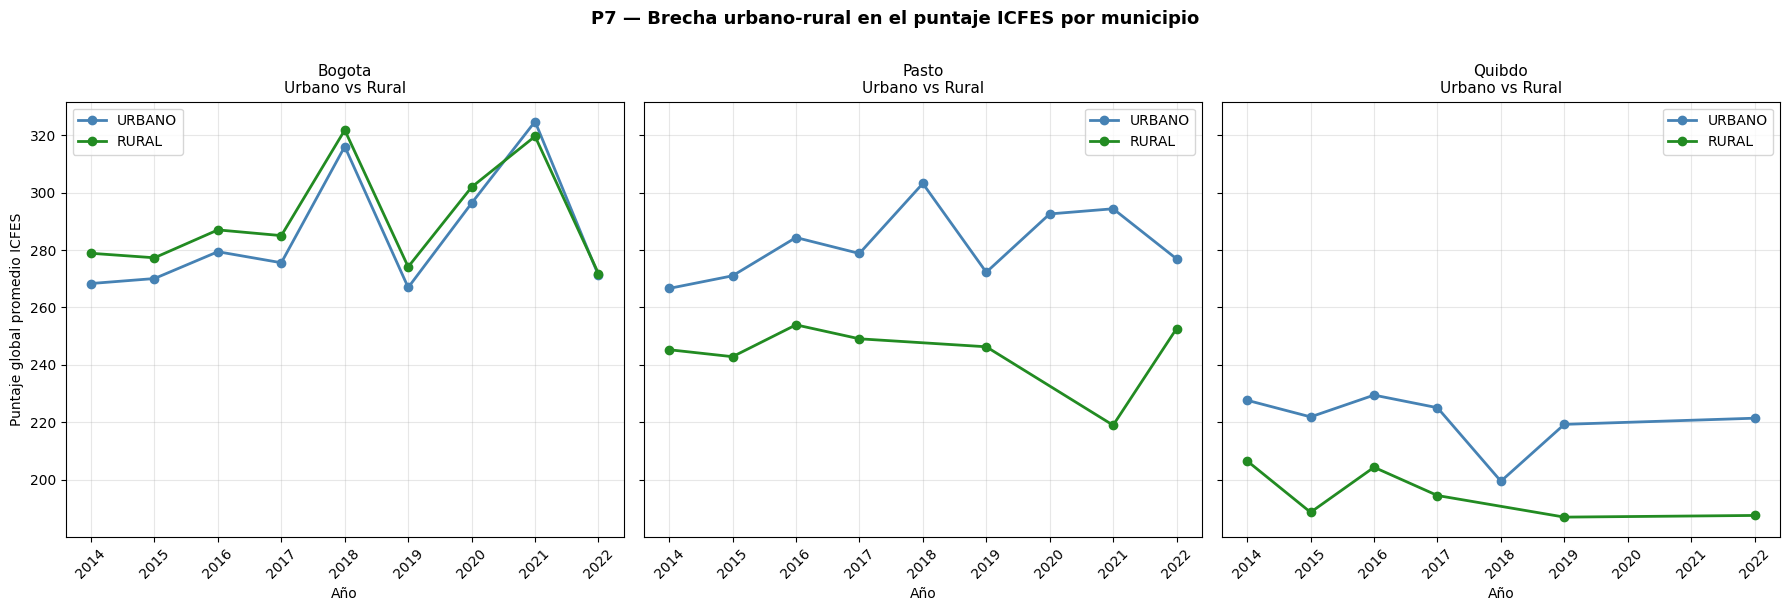


Brecha promedio (Urbano − Rural) por municipio:
COLE_MCPIO_UBICACION
BOGOTA    -5.42
PASTO     33.61
QUIBDO    29.37
Name: BRECHA, dtype: float64


In [77]:
df_p7 = dfICFES_mcpio \
    .filter(col("COLE_AREA_UBICACION").isin(["URBANO", "RURAL"])) \
    .filter(col("PUNT_GLOBAL_NUM").isNotNull()) \
    .groupBy("COLE_MCPIO_UBICACION", "AÑO", "COLE_AREA_UBICACION") \
    .agg(F.avg("PUNT_GLOBAL_NUM").alias("PUNTAJE_PROM")) \
    .orderBy("COLE_MCPIO_UBICACION", "AÑO").toPandas()

df_p7["AÑO"] = df_p7["AÑO"].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, mcpio in enumerate(["BOGOTA", "PASTO", "QUIBDO"]):
    sub = df_p7[df_p7["COLE_MCPIO_UBICACION"] == mcpio]
    if sub.empty:
        axes[i].set_title(f"{mcpio.title()}\n(sin datos)", fontsize=11)
        axes[i].axis('off')
        continue
    for area, color in zip(["URBANO", "RURAL"], ["steelblue", "forestgreen"]):
        s2 = sub[sub["COLE_AREA_UBICACION"] == area].sort_values("AÑO")
        axes[i].plot(s2["AÑO"], s2["PUNTAJE_PROM"],
                     marker="o", label=area, color=color, linewidth=2)
    axes[i].set_title(f"{mcpio.title()}\nUrbano vs Rural", fontsize=11)
    axes[i].set_xlabel("Año")
    if i == 0:
        axes[i].set_ylabel("Puntaje global promedio ICFES")
    axes[i].legend()
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].grid(alpha=0.3)

plt.suptitle("P7 — Brecha urbano-rural en el puntaje ICFES por municipio",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

df_p7_brecha = df_p7.pivot_table(index=["COLE_MCPIO_UBICACION", "AÑO"],
                                   columns="COLE_AREA_UBICACION",
                                   values="PUNTAJE_PROM")
df_p7_brecha["BRECHA"] = df_p7_brecha["URBANO"] - df_p7_brecha["RURAL"]
print("\nBrecha promedio (Urbano − Rural) por municipio:")
print(df_p7_brecha.groupby(level=0)["BRECHA"].mean().round(2))

### P8 ¿Los municipios del Grupo B presentan simultáneamente mayores tasas de deserción, menor internet y peores resultados ICFES?

In [105]:
# ── P8: Deserción + Internet + ICFES por municipio y año ──

# 1. Agregar deserción desde dfEdu_foco
df_desercion = dfEdu_foco \
    .groupBy("MCPIO_NORM", "AÑO") \
    .agg(F.avg("DESERCION").alias("DESERCION_PROM")) \
    .withColumnRenamed("MCPIO_NORM", "MUNICIPIO")

# 2. Traer accesos de internet normalizados (por año)
df_inet_p8 = dfInternet_foco \
    .drop("MUNICIPIO") \
    .withColumnRenamed("MUNICIPIO_NORM", "MUNICIPIO") \
    .groupBy("MUNICIPIO", "AÑO") \
    .agg(Fsum("TOTAL_ACCESOS").alias("TOTAL_ACCESOS"))

# 3. Unir todo en tabla comparativa
df_p8 = df_master \
    .select("MUNICIPIO", "AÑO", "GRUPO",
            "PUNTAJE_GLOBAL_PROM", "PROP_INTERNET_HOGAR", "TOTAL_ACCESOS") \
    .join(df_desercion, on=["MUNICIPIO", "AÑO"], how="left")

print("=== P8: Comparativa Grupo A vs Grupo B ===")
df_p8.orderBy("MUNICIPIO", "AÑO").show(30)

# 4. Resumen agregado por grupo (promedio histórico)
df_p8_resumen = df_p8 \
    .groupBy("MUNICIPIO", "GRUPO") \
    .agg(
        F.avg("PUNTAJE_GLOBAL_PROM").alias("ICFES_PROM"),
        F.avg("PROP_INTERNET_HOGAR").alias("PROP_INTERNET_HOGAR_PROM"),
        F.avg("TOTAL_ACCESOS").alias("ACCESOS_PROM"),
        F.avg("DESERCION_PROM").alias("DESERCION_PROM")
    )

print("=== Resumen histórico por municipio ===")
df_p8_resumen.orderBy("GRUPO", "MUNICIPIO").show()

=== P8: Comparativa Grupo A vs Grupo B ===


+---------+----+--------------------+-------------------+-------------------+-------------+--------------+
|MUNICIPIO| AÑO|               GRUPO|PUNTAJE_GLOBAL_PROM|PROP_INTERNET_HOGAR|TOTAL_ACCESOS|DESERCION_PROM|
+---------+----+--------------------+-------------------+-------------------+-------------+--------------+
|   BOGOTA|2014|Grupo A - Alto de...|  268.4251208255323| 0.8045801526717558|         NULL|          NULL|
|   BOGOTA|2015|Grupo A - Alto de...|  270.1382348379091| 0.8290658515102844|         NULL|          NULL|
|   BOGOTA|2016|Grupo A - Alto de...| 279.48603962109087| 0.8363646217212226|         NULL|          NULL|
|   BOGOTA|2017|Grupo A - Alto de...| 275.64855650261205| 0.8586240574180067|         NULL|          1.62|
|   BOGOTA|2018|Grupo A - Alto de...|  316.1683569979716| 0.9428246337647561|         NULL|          1.65|
|   BOGOTA|2019|Grupo A - Alto de...|   267.013748406543| 0.8839915548931943|         NULL|           1.6|
|   BOGOTA|2020|Grupo A - Alto de...|

[Stage 791:=====================================================> (27 + 1) / 28]

+---------+--------------------+------------------+------------------------+------------+------------------+
|MUNICIPIO|               GRUPO|        ICFES_PROM|PROP_INTERNET_HOGAR_PROM|ACCESOS_PROM|    DESERCION_PROM|
+---------+--------------------+------------------+------------------------+------------+------------------+
|   BOGOTA|Grupo A - Alto de...| 285.4568289927895|      0.8925940362135625|        NULL|1.6799999999999997|
|    PASTO|Grupo B - Alta vu...|280.20796715829766|      0.7440988808773534|    311829.0|             1.425|
|   QUIBDO|Grupo B - Alta vu...|220.14639015651795|      0.5963714410432911|    61146.75|            1.4325|
+---------+--------------------+------------------+------------------------+------------+------------------+



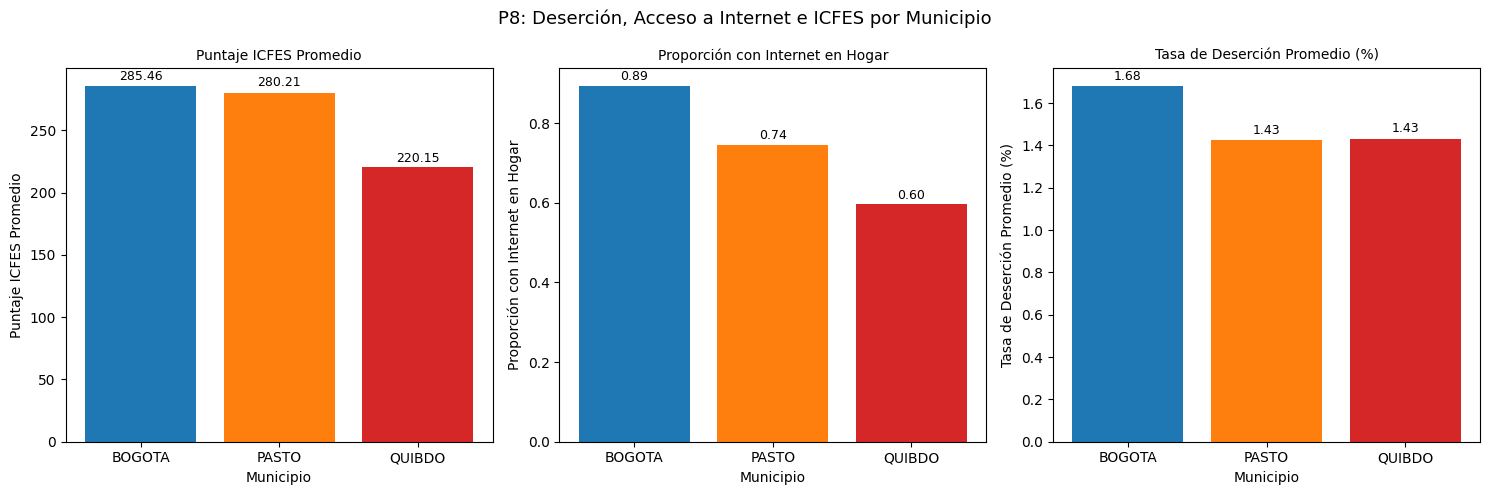

Gráfico P8 guardado.


In [106]:
# ── Visualización P8 ──
import matplotlib.pyplot as plt
import numpy as np

pdf_p8 = df_p8_resumen.toPandas()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("P8: Deserción, Acceso a Internet e ICFES por Municipio", fontsize=13)

colores = {"BOGOTA": "#1f77b4", "QUIBDO": "#d62728", "PASTO": "#ff7f0e"}
metricas = [
    ("ICFES_PROM",              "Puntaje ICFES Promedio"),
    ("PROP_INTERNET_HOGAR_PROM","Proporción con Internet en Hogar"),
    ("DESERCION_PROM",          "Tasa de Deserción Promedio (%)"),
]

for ax, (col_name, titulo) in zip(axes, metricas):
    bars = ax.bar(pdf_p8["MUNICIPIO"], pdf_p8[col_name],
                  color=[colores[m] for m in pdf_p8["MUNICIPIO"]])
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel("Municipio")
    ax.set_ylabel(titulo)
    for bar, val in zip(bars, pdf_p8[col_name]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01 * bar.get_height(),
                f"{val:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("P8_desercion_internet_icfes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico P8 guardado.")

---
# 5. Preparación de datos para modelado

In [109]:
from pyspark.sql.functions import col, when, regexp_extract, upper, trim
import pyspark.sql.functions as F

# ── 1. Educación padres → ordinal numérica ──
def map_educacion(df, col_origen, col_destino):
    return df.withColumn(col_destino,
        when(col(col_origen).like("%Ninguno%"), 0.0)
        .when(col(col_origen).like("%Primaria%incompleta%"), 1.0)
        .when(col(col_origen).like("%Primaria%completa%"), 2.0)
        .when(col(col_origen).like("%Secundaria%incompleta%"), 3.0)
        .when(col(col_origen).like("%Secundaria%completa%"), 4.0)
        .when(col(col_origen).like("%cnica%incompleta%"), 5.0)
        .when(col(col_origen).like("%cnica%completa%"), 6.0)
        .when(col(col_origen).like("%profesional%incompleta%"), 7.0)
        .when(col(col_origen).like("%profesional%completa%"), 8.0)
        .when(col(col_origen).like("%Postgrado%"), 9.0)
        .otherwise(None).cast("double")
    )

dfICFES_mcpio = map_educacion(dfICFES_mcpio, "FAMI_EDUCACIONMADRE", "EDU_MADRE_NUM")
dfICFES_mcpio = map_educacion(dfICFES_mcpio, "FAMI_EDUCACIONPADRE", "EDU_PADRE_NUM")

# ── 2. Personas en el hogar → numérico (punto medio del rango) ──
dfICFES_mcpio = dfICFES_mcpio.withColumn("PERSONAS_HOGAR_NUM",
    when(col("FAMI_PERSONASHOGAR") == "1 a 2", 1.5)
    .when(col("FAMI_PERSONASHOGAR") == "3 a 4", 3.5)
    .when(col("FAMI_PERSONASHOGAR") == "5 a 6", 5.5)
    .when(col("FAMI_PERSONASHOGAR") == "7 a 8", 7.5)
    .when(col("FAMI_PERSONASHOGAR") == "9 o más", 9.0)
    .otherwise(None).cast("double")
)

# ── 3. Colegio oficial binario ──
dfICFES_mcpio = dfICFES_mcpio.withColumn("COLE_OFICIAL_BIN",
    when(col("COLE_NATURALEZA") == "OFICIAL", 1.0)
    .otherwise(0.0)
)

# ── 4. Área urbana binario ──
dfICFES_mcpio = dfICFES_mcpio.withColumn("COLE_AREA_BIN",
    when(col("COLE_AREA_UBICACION") == "URBANO", 1.0)
    .otherwise(0.0)
)

# ── Verificación ──
print("Transformaciones aplicadas. Muestra:")
dfICFES_mcpio.select(
    "FAMI_EDUCACIONMADRE", "EDU_MADRE_NUM",
    "FAMI_PERSONASHOGAR",  "PERSONAS_HOGAR_NUM",
    "COLE_NATURALEZA",     "COLE_OFICIAL_BIN",
    "COLE_AREA_UBICACION", "COLE_AREA_BIN"
).show(5, truncate=False)

Transformaciones aplicadas. Muestra:
+------------------------------+-------------+------------------+------------------+---------------+----------------+-------------------+-------------+
|FAMI_EDUCACIONMADRE           |EDU_MADRE_NUM|FAMI_PERSONASHOGAR|PERSONAS_HOGAR_NUM|COLE_NATURALEZA|COLE_OFICIAL_BIN|COLE_AREA_UBICACION|COLE_AREA_BIN|
+------------------------------+-------------+------------------+------------------+---------------+----------------+-------------------+-------------+
|Técnica o tecnológica completa|6.0          |1 a 2             |1.5               |NO OFICIAL     |0.0             |URBANO             |1.0          |
|Técnica o tecnológica completa|6.0          |1 a 2             |1.5               |NO OFICIAL     |0.0             |URBANO             |1.0          |
|Primaria incompleta           |1.0          |5 a 6             |5.5               |OFICIAL        |1.0             |URBANO             |1.0          |
|Primaria incompleta           |1.0          |5 a 6

Todas las columnas están disponibles


Registros con datos completos para correlación: 387813



Matriz de correlación (Pearson)
                          ESTRATO_NUM  TIENE_INTERNET_BIN  \
ESTRATO_NUM                      1.00                0.21   
TIENE_INTERNET_BIN               0.21                1.00   
TIENE_COMPUTADOR_BIN             0.26                0.45   
TIENE_LAVADORA_BIN               0.19                0.26   
EDU_MADRE_NUM                    0.47                0.23   
EDU_PADRE_NUM                    0.49                0.22   
PERSONAS_HOGAR_NUM              -0.11               -0.00   
COLE_OFICIAL_BIN                -0.41               -0.16   
COLE_AREA_BIN                    0.04                0.10   
PUNT_MATEMATICAS                 0.32                0.18   
PUNT_LECTURA_CRITICA             0.31                0.18   
PUNT_C_NATURALES                 0.33                0.17   
PUNT_SOCIALES_CIUDADANAS         0.32                0.16   
PUNT_INGLES                      0.48                0.22   

                          TIENE_COMPUTADOR_BIN  TIE

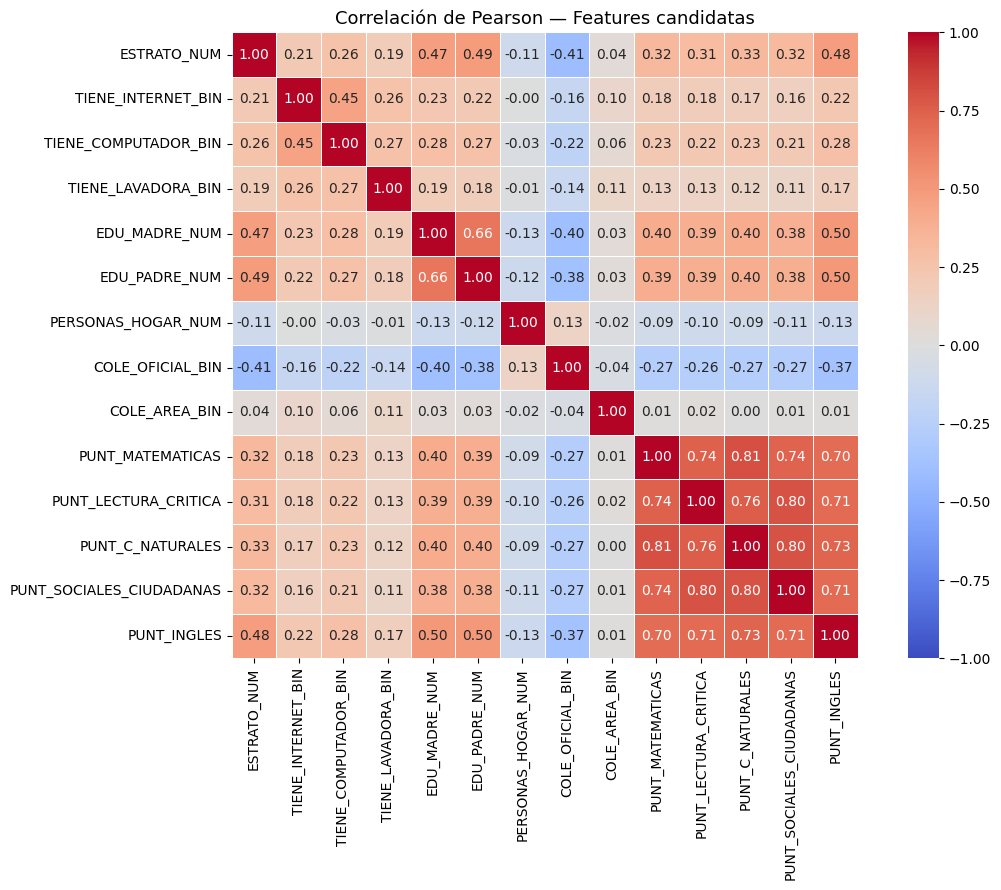

In [110]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import pandas as pd

# ── Asegurar tipos correctos antes de la correlación ──
dfICFES_mcpio = dfICFES_mcpio \
    .withColumn("PUNT_MATEMATICAS",        col("PUNT_MATEMATICAS").cast("double")) \
    .withColumn("PUNT_LECTURA_CRITICA",     col("PUNT_LECTURA_CRITICA").cast("double")) \
    .withColumn("PUNT_C_NATURALES",         col("PUNT_C_NATURALES").cast("double")) \
    .withColumn("PUNT_SOCIALES_CIUDADANAS", col("PUNT_SOCIALES_CIUDADANAS").cast("double")) \
    .withColumn("PUNT_INGLES",              col("PUNT_INGLES").cast("double")) \
    .withColumn("PUNT_GLOBAL_NUM",          col("PUNT_GLOBAL_NUM").cast("double"))

features_candidatas = [
    "ESTRATO_NUM",
    "TIENE_INTERNET_BIN",
    "TIENE_COMPUTADOR_BIN",
    "TIENE_LAVADORA_BIN",
    "EDU_MADRE_NUM",
    "EDU_PADRE_NUM",
    "PERSONAS_HOGAR_NUM",
    "COLE_OFICIAL_BIN",
    "COLE_AREA_BIN",
    "PUNT_MATEMATICAS",
    "PUNT_LECTURA_CRITICA",
    "PUNT_C_NATURALES",
    "PUNT_SOCIALES_CIUDADANAS",
    "PUNT_INGLES"
]

# ── Verificar que todas las columnas existen ──
columnas_disponibles = dfICFES_mcpio.columns
faltantes = [f for f in features_candidatas if f not in columnas_disponibles]
if faltantes:
    print(f"Columnas faltantes en dfICFES_mcpio: {faltantes}")
else:
    print("Todas las columnas están disponibles")

# ── Filtrar filas completas (sin ningún nulo en las features) ──
df_corr = dfICFES_mcpio \
    .select(features_candidatas + ["PUNT_GLOBAL_NUM"]) \
    .dropna()

print(f"Registros con datos completos para correlación: {df_corr.count()}")

# ── Ensamblar vector ──
assembler_corr = VectorAssembler(
    inputCols=features_candidatas,
    outputCol="features_corr",
    handleInvalid="skip"   # por si queda algún nulo residual
)
df_corr_vec = assembler_corr.transform(df_corr)

# ── Matriz de correlación de Pearson ──
matrix    = Correlation.corr(df_corr_vec, "features_corr", method="pearson")
corr_array = matrix.collect()[0]["pearson(features_corr)"].toArray()

df_corr_pd = pd.DataFrame(
    corr_array,
    index=features_candidatas,
    columns=features_candidatas
)

print("\nMatriz de correlación (Pearson)")
print(df_corr_pd.round(2))

umbral = 0.85
print(f"\n=== Pares con |correlación| > {umbral} ===")
encontrados = False
for i in range(len(features_candidatas)):
    for j in range(i + 1, len(features_candidatas)):
        val = corr_array[i][j]
        if abs(val) > umbral:
            print(f"  {features_candidatas[i]}  ↔  {features_candidatas[j]}:  {val:.3f}")
            encontrados = True

if not encontrados:
    print("  Ningún par supera el umbral")

# ── Heatmap ──
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 9))
sns.heatmap(
    df_corr_pd,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title("Correlación de Pearson — Features candidatas", fontsize=13)
plt.tight_layout()
plt.savefig("correlacion_features.png", dpi=150, bbox_inches="tight")
plt.show()

In [100]:
#Normalizacion de variables numericas

In [112]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

features_finales = [
    "ESTRATO_NUM",
    "TIENE_INTERNET_BIN",
    "TIENE_COMPUTADOR_BIN",
    "TIENE_LAVADORA_BIN",
    "EDU_MADRE_NUM",
    "EDU_PADRE_NUM",
    "PERSONAS_HOGAR_NUM",
    "COLE_OFICIAL_BIN",
    "COLE_AREA_BIN",
    "PUNT_MATEMATICAS",
    "PUNT_LECTURA_CRITICA",
    "PUNT_C_NATURALES",
    "PUNT_SOCIALES_CIUDADANAS",
    "PUNT_INGLES"
]

df_modelo = dfICFES_mcpio \
    .withColumnRenamed("COLE_MCPIO_UBICACION", "MUNICIPIO") \
    .select(features_finales + ["label", "MUNICIPIO", "GRUPO", "AÑO"]) \
    .dropna(subset=features_finales + ["label"])

print("Registros disponibles para modelado:", df_modelo.count())
print("\nDistribución de clases:")
df_modelo.groupBy("label").count().orderBy("label").show()
print("Distribución por municipio y clase:")
df_modelo.groupBy("MUNICIPIO", "GRUPO", "label").count() \
    .orderBy("MUNICIPIO", "label").show()

Registros disponibles para modelado: 387813

Distribución de clases:


+-----+------+
|label| count|
+-----+------+
|  0.0|268444|
|  1.0|119369|
+-----+------+

Distribución por municipio y clase:


[Stage 837:=====================================================> (27 + 1) / 28]

+---------+--------------------+-----+------+
|MUNICIPIO|               GRUPO|label| count|
+---------+--------------------+-----+------+
|   BOGOTA|Grupo A - Alto de...|  0.0|248587|
|   BOGOTA|Grupo A - Alto de...|  1.0|112116|
|    PASTO|Grupo B - Alta vu...|  0.0| 14158|
|    PASTO|Grupo B - Alta vu...|  1.0|  6871|
|   QUIBDO|Grupo B - Alta vu...|  0.0|  5699|
|   QUIBDO|Grupo B - Alta vu...|  1.0|   382|
+---------+--------------------+-----+------+



In [113]:
# Pipeline: ensamble + normalización
assembler = VectorAssembler(
    inputCols=features_finales,
    outputCol="features_raw",
    handleInvalid="skip"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True
)

pipeline_prep = Pipeline(stages=[assembler, scaler])
modelo_prep   = pipeline_prep.fit(df_modelo)
df_modelo_scaled = modelo_prep.transform(df_modelo)

print("Normalización aplicada")
df_modelo_scaled.select("features_raw", "features", "label").show(3, truncate=False)

Normalización aplicada
+--------------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|features_raw                                                  |features                                                                                                                                                                                                                                                                           |label|
+--------------------------------------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [114]:
# Split train / test 80-20
df_train, df_test = df_modelo_scaled.randomSplit([0.8, 0.2], seed=42)

print(f"Registros entrenamiento : {df_train.count()}")
print(f"Registros prueba        : {df_test.count()}")
print("\nClases en entrenamiento:")
df_train.groupBy("label").count().orderBy("label").show()
print("Clases en prueba:")
df_test.groupBy("label").count().orderBy("label").show()

Registros entrenamiento : 310279


Registros prueba        : 77534

Clases en entrenamiento:


+-----+------+
|label| count|
+-----+------+
|  0.0|214703|
|  1.0| 95576|
+-----+------+

Clases en prueba:


[Stage 853:=====================================================> (27 + 1) / 28]

+-----+-----+
|label|count|
+-----+-----+
|  0.0|53741|
|  1.0|23793|
+-----+-----+



# 6. Aplicación de las técnicas con MLlib sobre el clúster Spark

## 6.1 Modelo supervisado: Gradient Boosted Trees (GBT)

In [115]:
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# Experimento 1: parámetros base 
gbt_1 = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    maxIter=20,
    maxDepth=5,
    stepSize=0.1,
    seed=42
)

modelo_gbt_1 = gbt_1.fit(df_train)
pred_gbt_1   = modelo_gbt_1.transform(df_test)

print("GBT Experimento 1 entrenado")
pred_gbt_1.select("MUNICIPIO", "label", "prediction", "probability").show(5, truncate=False)

GBT Experimento 1 entrenado


[Stage 1060:>                                                       (0 + 1) / 1]

+---------+-----+----------+---------------------------------------+
|MUNICIPIO|label|prediction|probability                            |
+---------+-----+----------+---------------------------------------+
|QUIBDO   |0.0  |0.0       |[0.9575173840185045,0.0424826159814955]|
|PASTO    |0.0  |0.0       |[0.9575173840185045,0.0424826159814955]|
|QUIBDO   |0.0  |0.0       |[0.9575173840185045,0.0424826159814955]|
|PASTO    |0.0  |0.0       |[0.9575173840185045,0.0424826159814955]|
|PASTO    |0.0  |0.0       |[0.9575173840185045,0.0424826159814955]|
+---------+-----+----------+---------------------------------------+
only showing top 5 rows



In [116]:
# ── Función de métricas reutilizable ──
def evaluar_modelo(pred_df, nombre):
    evaluator_auc = BinaryClassificationEvaluator(
        labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
    )
    evaluator_acc = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="accuracy"
    )
    evaluator_f1 = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="f1"
    )
    evaluator_prec = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="weightedPrecision"
    )
    evaluator_rec = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="weightedRecall"
    )

    auc  = evaluator_auc.evaluate(pred_df)
    acc  = evaluator_acc.evaluate(pred_df)
    f1   = evaluator_f1.evaluate(pred_df)
    prec = evaluator_prec.evaluate(pred_df)
    rec  = evaluator_rec.evaluate(pred_df)

   
    print(f"  {nombre}")
    print(f"  AUC-ROC            : {auc:.4f}")
    print(f"  Accuracy           : {acc:.4f}")
    print(f"  F1 (weighted)      : {f1:.4f}")
    print(f"  Precision (weighted): {prec:.4f}")
    print(f"  Recall (weighted)  : {rec:.4f}")
    print(f"{'='*45}")
    return {"modelo": nombre, "AUC": auc, "Accuracy": acc, "F1": f1}

res_1 = evaluar_modelo(pred_gbt_1, "GBT — maxIter=20, maxDepth=5, lr=0.1")

[Stage 1078:==================================================>   (26 + 2) / 28]


  GBT — maxIter=20, maxDepth=5, lr=0.1
  AUC-ROC            : 0.9983
  Accuracy           : 0.9761
  F1 (weighted)      : 0.9761
  Precision (weighted): 0.9761
  Recall (weighted)  : 0.9761


In [117]:
# ── Experimento 2: más iteraciones y árbol más profundo ──
gbt_2 = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    maxIter=50,
    maxDepth=7,
    stepSize=0.05,
    seed=42
)

modelo_gbt_2 = gbt_2.fit(df_train)
pred_gbt_2   = modelo_gbt_2.transform(df_test)
res_2 = evaluar_modelo(pred_gbt_2, "GBT — maxIter=50, maxDepth=7, lr=0.05")

26/05/26 02:41:31 WARN DAGScheduler: Broadcasting large task binary with size 1004.1 KiB
26/05/26 02:41:32 WARN DAGScheduler: Broadcasting large task binary with size 1004.6 KiB
26/05/26 02:41:32 WARN DAGScheduler: Broadcasting large task binary with size 1005.2 KiB
26/05/26 02:41:33 WARN DAGScheduler: Broadcasting large task binary with size 1006.3 KiB
26/05/26 02:41:33 WARN DAGScheduler: Broadcasting large task binary with size 1008.6 KiB
26/05/26 02:41:33 WARN DAGScheduler: Broadcasting large task binary with size 1013.1 KiB
26/05/26 02:41:34 WARN DAGScheduler: Broadcasting large task binary with size 1022.2 KiB
26/05/26 02:41:34 WARN DAGScheduler: Broadcasting large task binary with size 1026.5 KiB
26/05/26 02:41:35 WARN DAGScheduler: Broadcasting large task binary with size 1026.9 KiB
26/05/26 02:41:35 WARN DAGScheduler: Broadcasting large task binary with size 1027.5 KiB
26/05/26 02:41:35 WARN DAGScheduler: Broadcasting large task binary with size 1028.6 KiB
26/05/26 02:41:36 WAR


  GBT — maxIter=50, maxDepth=7, lr=0.05
  AUC-ROC            : 0.9993
  Accuracy           : 0.9848
  F1 (weighted)      : 0.9848
  Precision (weighted): 0.9848
  Recall (weighted)  : 0.9848


In [118]:
# ── Experimento 3: árbol más conservador (regularización mayor) ──
gbt_3 = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    maxIter=30,
    maxDepth=4,
    stepSize=0.05,
    minInstancesPerNode=10,
    seed=42
)

modelo_gbt_3 = gbt_3.fit(df_train)
pred_gbt_3   = modelo_gbt_3.transform(df_test)
res_3 = evaluar_modelo(pred_gbt_3, "GBT — maxIter=30, maxDepth=4, lr=0.05")

[Stage 2064:====================================================> (27 + 1) / 28]


  GBT — maxIter=30, maxDepth=4, lr=0.05
  AUC-ROC            : 0.9971
  Accuracy           : 0.9690
  F1 (weighted)      : 0.9690
  Precision (weighted): 0.9689
  Recall (weighted)  : 0.9690


In [119]:
# ── Tabla comparativa de experimentos ──
import pandas as pd

resultados = pd.DataFrame([res_1, res_2, res_3])
print("\n=== Comparativa de experimentos GBT ===")
print(resultados.to_string(index=False))

mejor = resultados.loc[resultados["AUC"].idxmax()]
print(f"\n Mejor modelo: {mejor['modelo']} — AUC: {mejor['AUC']:.4f}")


=== Comparativa de experimentos GBT ===
                               modelo      AUC  Accuracy       F1
 GBT — maxIter=20, maxDepth=5, lr=0.1 0.998264  0.976140 0.976122
GBT — maxIter=50, maxDepth=7, lr=0.05 0.999306  0.984794 0.984790
GBT — maxIter=30, maxDepth=4, lr=0.05 0.997081  0.968994 0.968960

 Mejor modelo: GBT — maxIter=50, maxDepth=7, lr=0.05 — AUC: 0.9993



=== Importancia de variables (mejor GBT) ===
                 Feature  Importancia
        PUNT_C_NATURALES     0.549620
PUNT_SOCIALES_CIUDADANAS     0.181838
        PUNT_MATEMATICAS     0.113574
    PUNT_LECTURA_CRITICA     0.106040
             PUNT_INGLES     0.047236
           EDU_PADRE_NUM     0.000439
           EDU_MADRE_NUM     0.000404
             ESTRATO_NUM     0.000393
      PERSONAS_HOGAR_NUM     0.000227
           COLE_AREA_BIN     0.000080
        COLE_OFICIAL_BIN     0.000057
    TIENE_COMPUTADOR_BIN     0.000036
      TIENE_LAVADORA_BIN     0.000029
      TIENE_INTERNET_BIN     0.000028


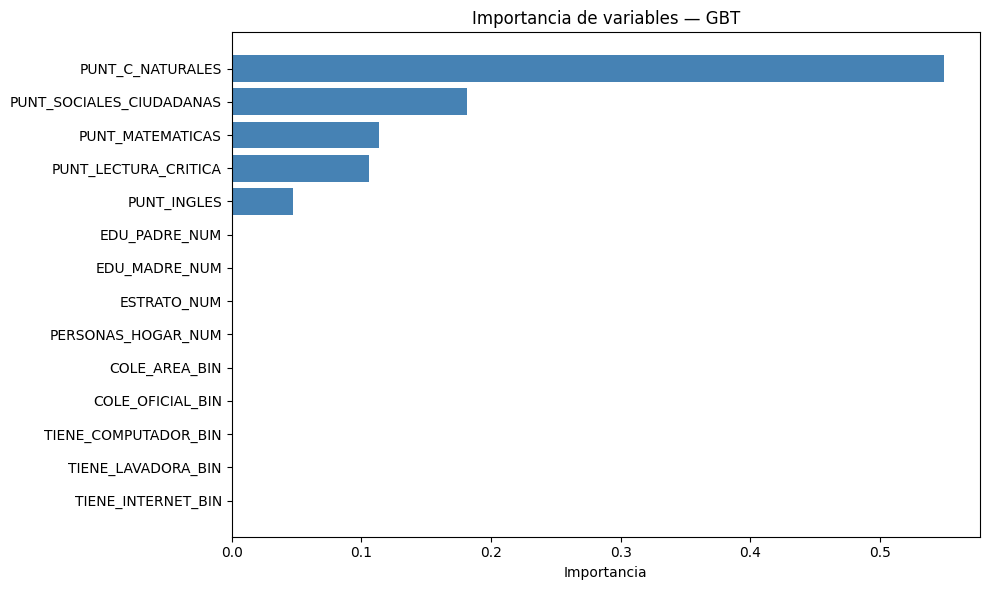

In [120]:
# ── Importancia de variables del mejor modelo ──
# Cambiar modelo_gbt_X por el que haya obtenido mejor AUC
mejor_modelo_gbt = modelo_gbt_2   # ajustar según resultados

importancias = mejor_modelo_gbt.featureImportances
nombres = features_finales

imp_df = pd.DataFrame({
    "Feature": nombres,
    "Importancia": importancias.toArray()
}).sort_values("Importancia", ascending=False)

print("\n=== Importancia de variables (mejor GBT) ===")
print(imp_df.to_string(index=False))

# Gráfico
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(imp_df["Feature"], imp_df["Importancia"], color="steelblue")
plt.xlabel("Importancia")
plt.title("Importancia de variables — GBT")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("gbt_importancia_variables.png", dpi=150, bbox_inches="tight")
plt.show()

## Matriz de Confusión

/Almacen/Spark/python/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
26/05/26 02:48:57 WARN DAGScheduler: Broadcasting large task binary with size 1321.3 KiB
26/05/26 02:49:06 WARN DAGScheduler: Broadcasting large task binary with size 1333.6 KiB
                                                                                

Matriz de confusión:
[[53171   570]
 [  609 23184]]


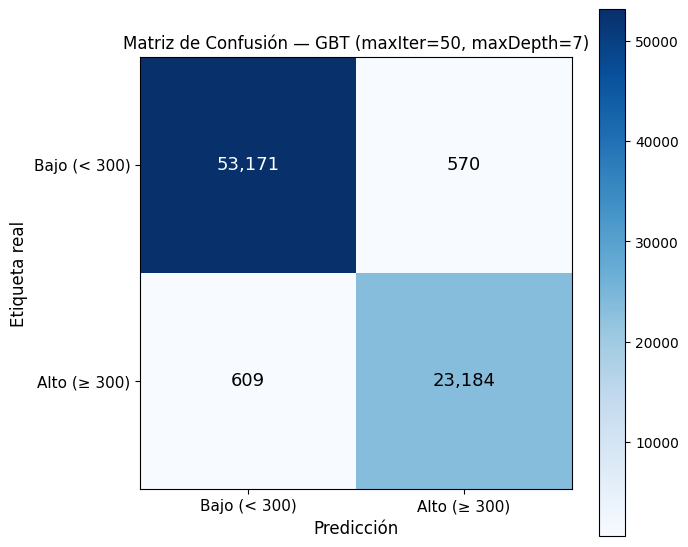

In [121]:
# ── Matriz de confusión ──
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pyspark.mllib.evaluation import MulticlassMetrics

# Necesitamos RDD de (prediction, label) para la matriz
pred_rdd = pred_gbt_2.select("prediction", "label") \
    .rdd.map(lambda row: (float(row.prediction), float(row.label)))

metrics = MulticlassMetrics(pred_rdd)
cm = metrics.confusionMatrix().toArray().astype(int)

print("Matriz de confusión:")
print(cm)

# Gráfico
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)

clases = ["Bajo (< 300)", "Alto (≥ 300)"]
tick_marks = [0, 1]
ax.set_xticks(tick_marks); ax.set_xticklabels(clases, fontsize=11)
ax.set_yticks(tick_marks); ax.set_yticklabels(clases, fontsize=11)

# Valores dentro de celdas
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}",
                ha="center", va="center", fontsize=13,
                color="white" if cm[i, j] > thresh else "black")

ax.set_ylabel("Etiqueta real", fontsize=12)
ax.set_xlabel("Predicción", fontsize=12)
ax.set_title("Matriz de Confusión — GBT (maxIter=50, maxDepth=7)", fontsize=12)
plt.tight_layout()
plt.savefig("gbt_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 6.2 Modelo no supervisado: Bisecting K-Means

In [124]:
from pyspark.ml.clustering import BisectingKMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt
import pandas as pd

# ── Features para clustering (solo socioeconómicas + conectividad, SIN subpuntajes)
# Para clustering queremos segmentar perfiles de estudiante, no predecir rendimiento
features_cluster = [
    "ESTRATO_NUM",
    "TIENE_INTERNET_BIN",
    "TIENE_COMPUTADOR_BIN",
    "TIENE_LAVADORA_BIN",
    "EDU_MADRE_NUM",
    "EDU_PADRE_NUM",
    "PERSONAS_HOGAR_NUM",
    "COLE_OFICIAL_BIN",
    "COLE_AREA_BIN"
]

# Reensamblar y normalizar solo con features de clustering
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

assembler_cl = VectorAssembler(
    inputCols=features_cluster,
    outputCol="features_cl_raw",
    handleInvalid="skip"
)
scaler_cl = StandardScaler(
    inputCol="features_cl_raw",
    outputCol="features_cl",
    withMean=True, withStd=True
)

pipeline_cl = Pipeline(stages=[assembler_cl, scaler_cl])

df_cluster = df_modelo.dropna(subset=features_cluster)
modelo_cl  = pipeline_cl.fit(df_cluster)
df_cluster_scaled = modelo_cl.transform(df_cluster)

print(f"Registros para clustering: {df_cluster_scaled.count()}")

[Stage 2086:==================================================>   (26 + 2) / 28]

Registros para clustering: 387813


In [127]:
# ── Diagnóstico: ver qué hay en df_cluster_scaled ──
print("Total registros:", df_cluster_scaled.count())
print("Municipios:")
df_cluster_scaled.groupBy("MUNICIPIO").count().show()

# Probar manualmente k=3 antes del loop
bkm_test = BisectingKMeans(
    featuresCol="features_cl",
    predictionCol="cluster",
    k=3, seed=42, maxIter=20
)
modelo_test = bkm_test.fit(df_cluster_scaled)
pred_test   = modelo_test.transform(df_cluster_scaled)

print("Clusters generados:")
pred_test.groupBy("cluster").count().orderBy("cluster").show()

Total registros: 387813
Municipios:


+---------+------+
|MUNICIPIO| count|
+---------+------+
|    PASTO| 21029|
|   QUIBDO|  6081|
|   BOGOTA|360703|
+---------+------+



Clusters generados:


[Stage 2275:====================================================> (27 + 1) / 28]

+-------+------+
|cluster| count|
+-------+------+
|      0|169372|
|      1|218441|
+-------+------+



In [130]:
from pyspark.ml.clustering import KMeans

resultados_k = []

for k in range(2, 8):
    km = KMeans(
        featuresCol="features_cl",
        predictionCol="cluster",
        k=k, seed=42, maxIter=50,
        tol=1e-4
    )
    modelo_km = km.fit(df_cluster_scaled)
    pred_km   = modelo_km.transform(df_cluster_scaled)

    n_clusters = pred_km.select("cluster").distinct().count()
    print(f"  k={k} → clusters reales: {n_clusters}", end="")

    if n_clusters > 1:
        silhouette = evaluator_cl.evaluate(pred_km)
        wssse      = modelo_km.summary.trainingCost
        resultados_k.append({"k": k, "Silhouette": silhouette, "WSSSE": wssse})
        print(f"  Silhouette={silhouette:.4f}  WSSSE={wssse:.2f}")
    else:
        print("  Solo 1 cluster, omitiendo")

df_ks = pd.DataFrame(resultados_k)
print("\n=== Resumen Elbow ===")
print(df_ks.to_string(index=False))

  k=2 → clusters reales: 2

  Silhouette=0.3075  WSSSE=2743108.57


  k=3 → clusters reales: 3

  Silhouette=0.3636  WSSSE=2301608.28


  k=4 → clusters reales: 4

...

  k=6 → clusters reales: 6

  Silhouette=0.3746  WSSSE=1533276.90


  k=7 → clusters reales: 7

[Stage 3848:====================================================> (27 + 1) / 28]

  Silhouette=0.3314  WSSSE=1609676.97

=== Resumen Elbow ===
 k  Silhouette        WSSSE
 2    0.307523 2.743109e+06
 3    0.363574 2.301608e+06
 4    0.355109 2.080025e+06
 5    0.288302 1.907836e+06
 6    0.374566 1.533277e+06
 7    0.331419 1.609677e+06


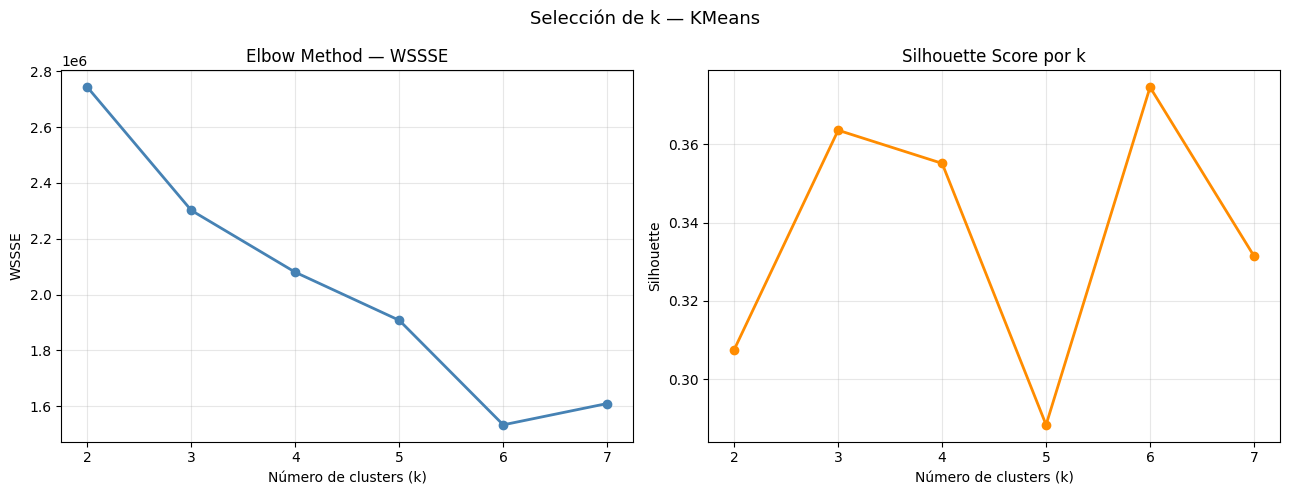

In [131]:
# ── Gráfico Elbow + Silhouette ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(df_ks["k"], df_ks["WSSSE"], marker="o", color="steelblue", lw=2)
axes[0].set_title("Elbow Method — WSSSE", fontsize=12)
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("WSSSE")
axes[0].grid(alpha=0.3)

axes[1].plot(df_ks["k"], df_ks["Silhouette"], marker="o", color="darkorange", lw=2)
axes[1].set_title("Silhouette Score por k", fontsize=12)
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette")
axes[1].grid(alpha=0.3)

plt.suptitle("Selección de k — KMeans", fontsize=13)
plt.tight_layout()
plt.savefig("kmeans_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

In [132]:
# ── Modelo final con k=6 ──
km_final = KMeans(
    featuresCol="features_cl",
    predictionCol="cluster",
    k=6, seed=42, maxIter=50, tol=1e-4
)
modelo_km_final = km_final.fit(df_cluster_scaled)
df_clustered    = modelo_km_final.transform(df_cluster_scaled)

print("Distribución de estudiantes por cluster:")
df_clustered.groupBy("cluster").count().orderBy("cluster").show()

Distribución de estudiantes por cluster:


[Stage 3913:==================================================>   (26 + 2) / 28]

+-------+------+
|cluster| count|
+-------+------+
|      0|122467|
|      1|  5735|
|      2| 88680|
|      3| 75919|
|      4| 35919|
|      5| 59093|
+-------+------+



In [133]:
# ── Perfil de cada cluster (medias de features originales, sin escalar) ──
import pyspark.sql.functions as F

perfil_clusters = df_clustered.groupBy("cluster").agg(
    F.count("*").alias("N_ESTUDIANTES"),
    F.avg("ESTRATO_NUM").alias("ESTRATO_PROM"),
    F.avg("TIENE_INTERNET_BIN").alias("PROP_INTERNET"),
    F.avg("TIENE_COMPUTADOR_BIN").alias("PROP_COMPUTADOR"),
    F.avg("TIENE_LAVADORA_BIN").alias("PROP_LAVADORA"),
    F.avg("EDU_MADRE_NUM").alias("EDU_MADRE_PROM"),
    F.avg("EDU_PADRE_NUM").alias("EDU_PADRE_PROM"),
    F.avg("PERSONAS_HOGAR_NUM").alias("PERSONAS_HOGAR_PROM"),
    F.avg("COLE_OFICIAL_BIN").alias("PROP_OFICIAL"),
    F.avg("COLE_AREA_BIN").alias("PROP_URBANO"),
    F.avg("PUNT_MATEMATICAS").alias("PUNT_MATE_PROM"),
    F.avg("PUNT_LECTURA_CRITICA").alias("PUNT_LECT_PROM"),
    F.avg("label").alias("PROP_PUNTAJE_ALTO")
).orderBy("cluster")

print("Perfil de clusters")
perfil_clusters.show(truncate=False)

=== Perfil de clusters ===


[Stage 3916:====================================================> (27 + 1) / 28]

+-------+-------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+-------------------+-----------+------------------+------------------+-------------------+
|cluster|N_ESTUDIANTES|ESTRATO_PROM      |PROP_INTERNET     |PROP_COMPUTADOR   |PROP_LAVADORA     |EDU_MADRE_PROM    |EDU_PADRE_PROM    |PERSONAS_HOGAR_PROM|PROP_OFICIAL       |PROP_URBANO|PUNT_MATE_PROM    |PUNT_LECT_PROM    |PROP_PUNTAJE_ALTO  |
+-------+-------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+-------------------+-----------+------------------+------------------+-------------------+
|0      |122467       |2.2180015841002065|0.9996407195407743|1.0               |1.0               |4.005283055843615 |3.5918165709946352|4.537512146129162  |1.0                |1.0        |53.276531637094074|54.95987490507647 |0.2030097903925139 |
|1      

In [134]:
# ── Composición de municipios por cluster ──
print("=== Municipio por cluster ===")
df_clustered.groupBy("cluster", "MUNICIPIO").count() \
    .orderBy("cluster", "MUNICIPIO").show()

=== Municipio por cluster ===


[Stage 3919:====================================================> (27 + 1) / 28]

+-------+---------+------+
|cluster|MUNICIPIO| count|
+-------+---------+------+
|      0|   BOGOTA|116326|
|      0|    PASTO|  4532|
|      0|   QUIBDO|  1609|
|      1|   BOGOTA|  3343|
|      1|    PASTO|  2289|
|      1|   QUIBDO|   103|
|      2|   BOGOTA| 84314|
|      2|    PASTO|  3812|
|      2|   QUIBDO|   554|
|      3|   BOGOTA| 73771|
|      3|    PASTO|  1997|
|      3|   QUIBDO|   151|
|      4|   BOGOTA| 29312|
|      4|    PASTO|  5583|
|      4|   QUIBDO|  1024|
|      5|   BOGOTA| 53637|
|      5|    PASTO|  2816|
|      5|   QUIBDO|  2640|
+-------+---------+------+



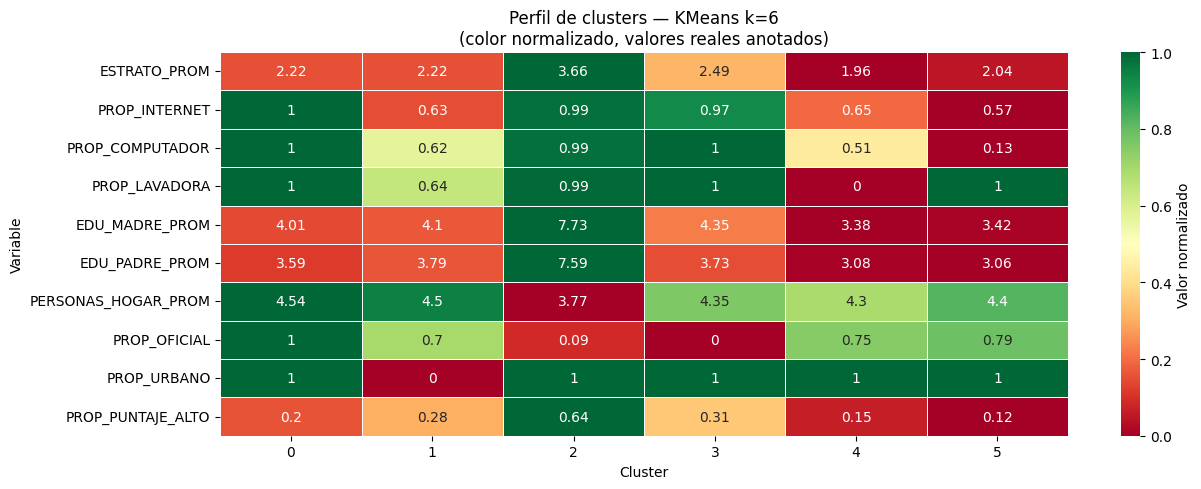

In [135]:
# ── Heatmap de perfiles ──
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

pdf_perfil = perfil_clusters.toPandas().set_index("cluster")

# Variables a graficar (normalizadas 0-1 para comparabilidad visual)
vars_heatmap = [
    "ESTRATO_PROM", "PROP_INTERNET", "PROP_COMPUTADOR",
    "PROP_LAVADORA", "EDU_MADRE_PROM", "EDU_PADRE_PROM",
    "PERSONAS_HOGAR_PROM", "PROP_OFICIAL", "PROP_URBANO",
    "PROP_PUNTAJE_ALTO"
]

df_heat = pdf_perfil[vars_heatmap].copy()
# Normalizar cada columna entre 0 y 1
df_heat = (df_heat - df_heat.min()) / (df_heat.max() - df_heat.min())

plt.figure(figsize=(13, 5))
sns.heatmap(
    df_heat.T,
    annot=pdf_perfil[vars_heatmap].T.round(2),  # valores reales como anotación
    fmt="g",
    cmap="RdYlGn", center=0.5,
    linewidths=0.5, cbar_kws={"label": "Valor normalizado"}
)
plt.title("Perfil de clusters — KMeans k=6\n(color normalizado, valores reales anotados)", fontsize=12)
plt.xlabel("Cluster")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig("kmeans_perfiles_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

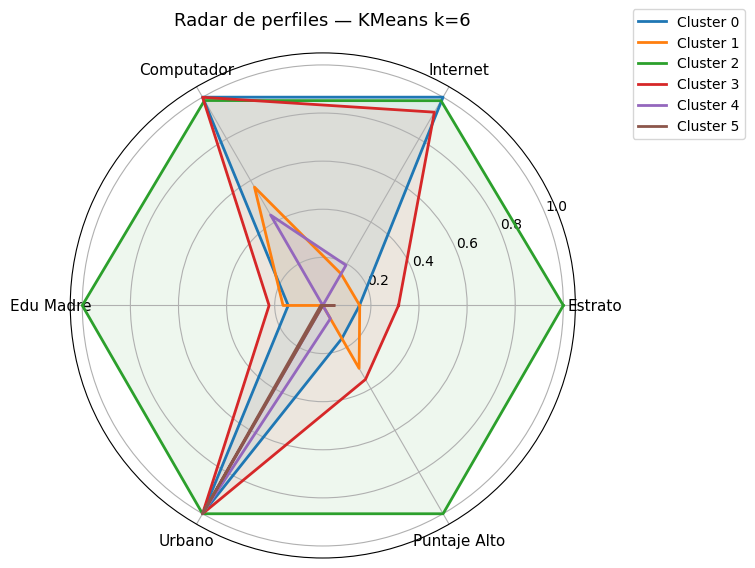

In [136]:
# ── Radar chart por cluster ──
from matplotlib.patches import FancyArrowPatch

vars_radar = [
    "ESTRATO_PROM", "PROP_INTERNET", "PROP_COMPUTADOR",
    "EDU_MADRE_PROM", "PROP_URBANO", "PROP_PUNTAJE_ALTO"
]
labels_radar = [
    "Estrato", "Internet", "Computador",
    "Edu Madre", "Urbano", "Puntaje Alto"
]

# Normalizar
df_radar = pdf_perfil[vars_radar].copy()
df_radar = (df_radar - df_radar.min()) / (df_radar.max() - df_radar.min())

N = len(vars_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = plt.cm.tab10.colors

for i, row in df_radar.iterrows():
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, lw=2, label=f"Cluster {i}", color=colors[i])
    ax.fill(angles, vals, alpha=0.08, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=11)
ax.set_title("Radar de perfiles — KMeans k=6", fontsize=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.savefig("kmeans_radar_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

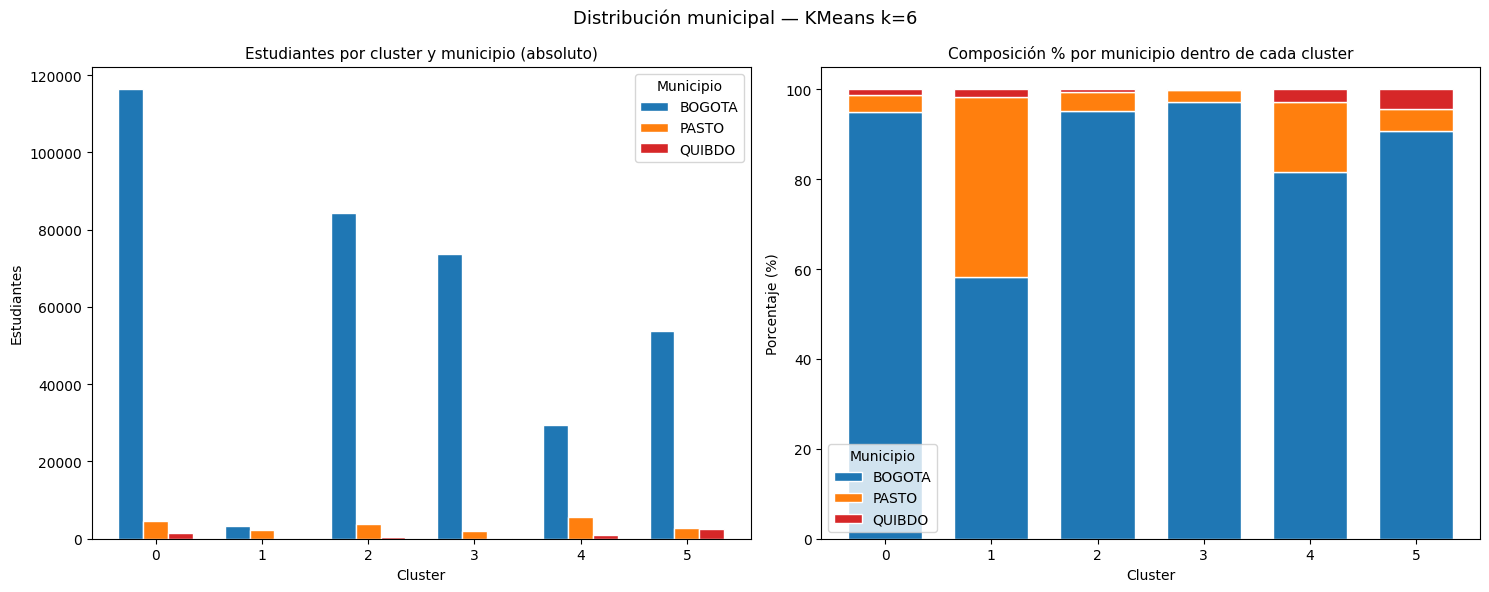

In [137]:
# ── Gráfico de composición municipal por cluster ──
pdf_mcpio = df_clustered.groupBy("cluster", "MUNICIPIO").count().toPandas()
pdf_pivot  = pdf_mcpio.pivot(index="cluster", columns="MUNICIPIO", values="count").fillna(0)
pdf_pivot_pct = pdf_pivot.div(pdf_pivot.sum(axis=1), axis=0) * 100

colores_mcpio = {"BOGOTA": "#1f77b4", "PASTO": "#ff7f0e", "QUIBDO": "#d62728"}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Composición absoluta
pdf_pivot.plot(kind="bar", ax=axes[0], color=[colores_mcpio[c] for c in pdf_pivot.columns],
               edgecolor="white", width=0.7)
axes[0].set_title("Estudiantes por cluster y municipio (absoluto)", fontsize=11)
axes[0].set_xlabel("Cluster"); axes[0].set_ylabel("Estudiantes")
axes[0].legend(title="Municipio")
axes[0].tick_params(axis='x', rotation=0)

# Composición porcentual
pdf_pivot_pct.plot(kind="bar", stacked=True, ax=axes[1],
                   color=[colores_mcpio[c] for c in pdf_pivot_pct.columns],
                   edgecolor="white", width=0.7)
axes[1].set_title("Composición % por municipio dentro de cada cluster", fontsize=11)
axes[1].set_xlabel("Cluster"); axes[1].set_ylabel("Porcentaje (%)")
axes[1].legend(title="Municipio")
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle("Distribución municipal — KMeans k=6", fontsize=13)
plt.tight_layout()
plt.savefig("kmeans_composicion_municipal.png", dpi=150, bbox_inches="tight")
plt.show()

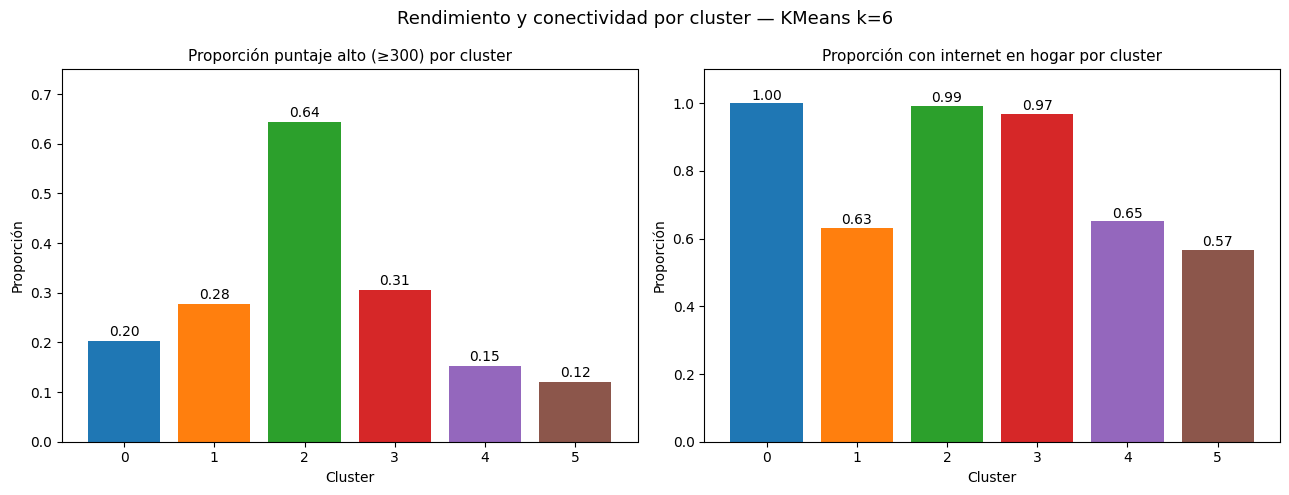

In [138]:
# ── Gráfico de puntaje promedio e internet por cluster ──
pdf_p = perfil_clusters.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colores_cl = plt.cm.tab10.colors

axes[0].bar(pdf_p["cluster"], pdf_p["PROP_PUNTAJE_ALTO"],
            color=[colores_cl[i] for i in pdf_p["cluster"]])
axes[0].set_title("Proporción puntaje alto (≥300) por cluster", fontsize=11)
axes[0].set_xlabel("Cluster"); axes[0].set_ylabel("Proporción")
axes[0].set_ylim(0, 0.75)
for i, v in enumerate(pdf_p["PROP_PUNTAJE_ALTO"]):
    axes[0].text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=10)

axes[1].bar(pdf_p["cluster"], pdf_p["PROP_INTERNET"],
            color=[colores_cl[i] for i in pdf_p["cluster"]])
axes[1].set_title("Proporción con internet en hogar por cluster", fontsize=11)
axes[1].set_xlabel("Cluster"); axes[1].set_ylabel("Proporción")
axes[1].set_ylim(0, 1.1)
for i, v in enumerate(pdf_p["PROP_INTERNET"]):
    axes[1].text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=10)

plt.suptitle("Rendimiento y conectividad por cluster — KMeans k=6", fontsize=13)
plt.tight_layout()
plt.savefig("kmeans_rendimiento_internet.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
sparkB.stop()
print("Sesión de Spark cerrada correctamente.")